# Composer Identification using Machine Learning and Deep Learning

## Project Overview

Music composers exhibit unique stylistic characteristics reflected in melody, rhythm, harmony, note density, tempo, and dynamics. These characteristics can be transformed into numerical features and learned by machine learning algorithms.

This project aims to classify the composer of a MIDI composition using both traditional Machine Learning and Deep Learning techniques.

---

### Objectives

- Build a comprehensive dataset from MIDI files
- Extract meaningful musical features
- Perform Exploratory Data Analysis (EDA)
- Train multiple Machine Learning models
- Develop Deep Learning architectures
- Compare all models using standard evaluation metrics

---

### Workflow

```
MIDI Files
      │
      ▼
Feature Extraction
      │
      ▼
Exploratory Data Analysis
      │
      ▼
Feature Engineering
      │
      ▼
Machine Learning Models
      │
      ▼
Deep Learning Models
      │
      ▼
Performance Comparison
```

# Contents

1. Import Libraries
2. Dataset Overview
3. Exploratory Data Analysis
4. Feature Engineering
5. Traditional Machine Learning
6. Hyperparameter Optimization
7. Sequence Modeling
8. CNN
9. LSTM
10. Transfer Learning
11. Model Comparison
12. Conclusion

# Import Required Libraries

This section imports all the libraries required throughout the project.

The imported packages cover:

- Data manipulation
- Data visualization
- MIDI parsing
- Machine Learning
- Deep Learning
- Model evaluation

In [ ]:
# ============================================================
# Import Required Libraries
# ============================================================

import os
import random
import warnings

warnings.filterwarnings("ignore")

# Install PrettyMIDI (only if running on Colab)
!pip -q install pretty_midi

# Numerical Computing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# MIDI Processing
import pretty_midi

# Machine Learning
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

# Deep Learning
import tensorflow as tf

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


# Dataset Configuration

The dataset is organized into three subsets:

- Training Set
- Validation Set
- Testing Set

Each folder contains one subdirectory for every composer, where each subdirectory stores the corresponding MIDI files.

In [ ]:
# ============================================================
# Dataset Paths
# ============================================================

train_dir = "/content/drive/MyDrive/Composer_Dataset/NN_midi_files_extended/train"
val_dir   = "/content/drive/MyDrive/Composer_Dataset/NN_midi_files_extended/dev"
test_dir  = "/content/drive/MyDrive/Composer_Dataset/NN_midi_files_extended/test"

print("Training :", train_dir)
print("Validation :", val_dir)
print("Testing :", test_dir)

Training : /content/drive/MyDrive/Composer_Dataset/NN_midi_files_extended/train
Validation : /content/drive/MyDrive/Composer_Dataset/NN_midi_files_extended/dev
Testing : /content/drive/MyDrive/Composer_Dataset/NN_midi_files_extended/test


# Dataset Statistics

Before extracting musical features, it is important to understand the composition of the dataset.

The following function computes:

- Number of composers
- Number of MIDI files
- Distribution of samples across classes

This helps identify any class imbalance before training the models.

In [ ]:
def dataset_statistics(folder):

    composers = sorted([
        d for d in os.listdir(folder)
        if os.path.isdir(os.path.join(folder, d))
    ])

    stats = []

    total_files = 0

    for composer in composers:

        composer_path = os.path.join(folder, composer)

        midi_files = [
            f for f in os.listdir(composer_path)
            if f.lower().endswith((".mid", ".midi"))
        ]

        total_files += len(midi_files)

        stats.append({
            "Composer": composer,
            "Files": len(midi_files)
        })

    stats_df = pd.DataFrame(stats)

    print("=" * 60)
    print(f"Dataset : {folder}")
    print("=" * 60)
    print(f"Number of composers : {len(composers)}")
    print(f"Total MIDI files    : {total_files}")
    print(f"Average per class   : {total_files/len(composers):.2f}")

    display(stats_df)

    return stats_df

# Generate Dataset Statistics

Using the previously defined function, we calculate the statistics separately for:

- Training Dataset
- Validation Dataset
- Testing Dataset

In [ ]:
train_stats = dataset_statistics(train_dir)
val_stats = dataset_statistics(val_dir)
test_stats = dataset_statistics(test_dir)

Dataset : /content/drive/MyDrive/Composer_Dataset/NN_midi_files_extended/train
Number of composers : 9
Total MIDI files    : 369
Average per class   : 41.00


,Composer,Files
0,bach,42
1,bartok,41
2,byrd,42
3,chopin,41
4,handel,41
5,hummel,42
6,mendelssohn,41
7,mozart,41
8,schumann,38


Dataset : /content/drive/MyDrive/Composer_Dataset/NN_midi_files_extended/dev
Number of composers : 9
Total MIDI files    : 35
Average per class   : 3.89


,Composer,Files
0,bach,4
1,bartok,4
2,byrd,4
3,chopin,4
4,handel,4
5,hummel,4
6,mendelssohn,4
7,mozart,4
8,schumann,3


Dataset : /content/drive/MyDrive/Composer_Dataset/NN_midi_files_extended/test
Number of composers : 9
Total MIDI files    : 35
Average per class   : 3.89


,Composer,Files
0,bach,4
1,bartok,4
2,byrd,4
3,chopin,4
4,handel,4
5,hummel,4
6,mendelssohn,4
7,mozart,4
8,schumann,3


In [ ]:
display(train_stats)

print("Number of composers :", len(train_stats))
print("Training samples :", train_stats["Files"].sum())

,Composer,Files
0,bach,42
1,bartok,41
2,byrd,42
3,chopin,41
4,handel,41
5,hummel,42
6,mendelssohn,41
7,mozart,41
8,schumann,38


Number of composers : 9
Training samples : 369


# Training Dataset Distribution

The following visualization illustrates the number of MIDI files available for each composer.

A relatively balanced dataset helps prevent the model from becoming biased toward any specific composer.

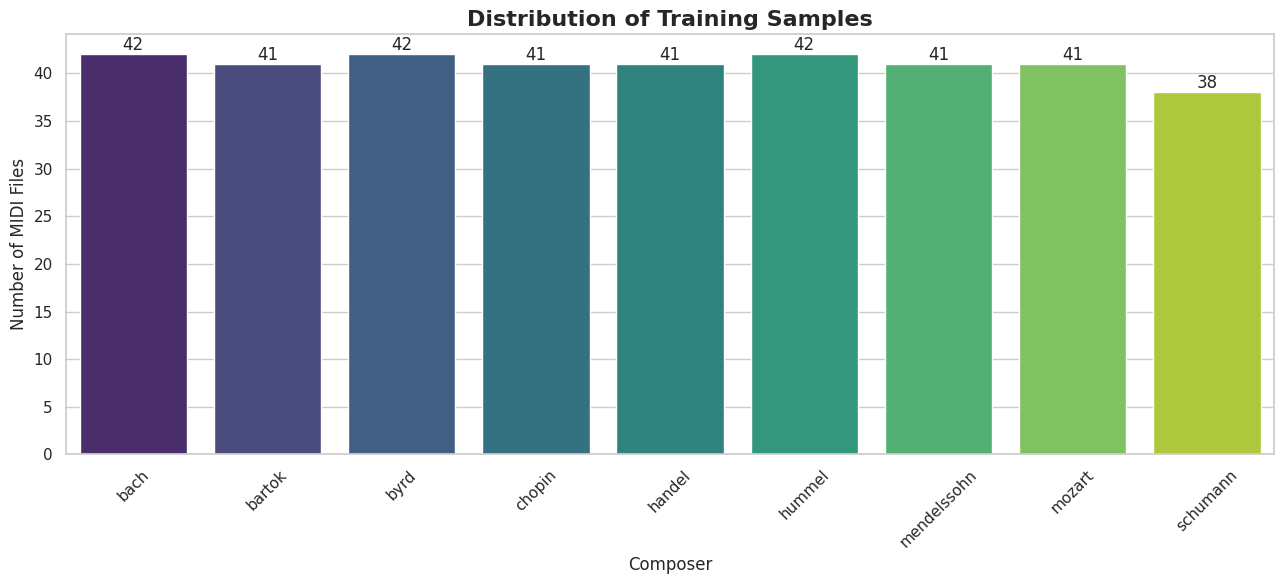

In [ ]:
fig, ax = plt.subplots(figsize=(13,6))

sns.barplot(
    data=train_stats,
    x="Composer",
    y="Files",
    palette="viridis",
    ax=ax
)

ax.set_title(
    "Distribution of Training Samples",
    fontsize=16,
    weight="bold"
)

ax.set_xlabel("Composer")
ax.set_ylabel("Number of MIDI Files")

plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()

plt.show()

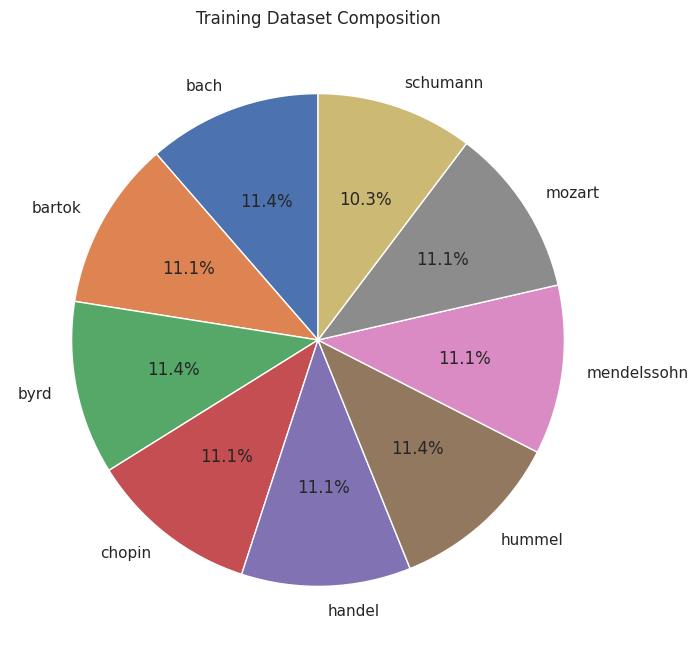

In [ ]:
plt.figure(figsize=(8,8))

train_stats.set_index("Composer")["Files"].plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")
plt.title("Training Dataset Composition")
plt.show()

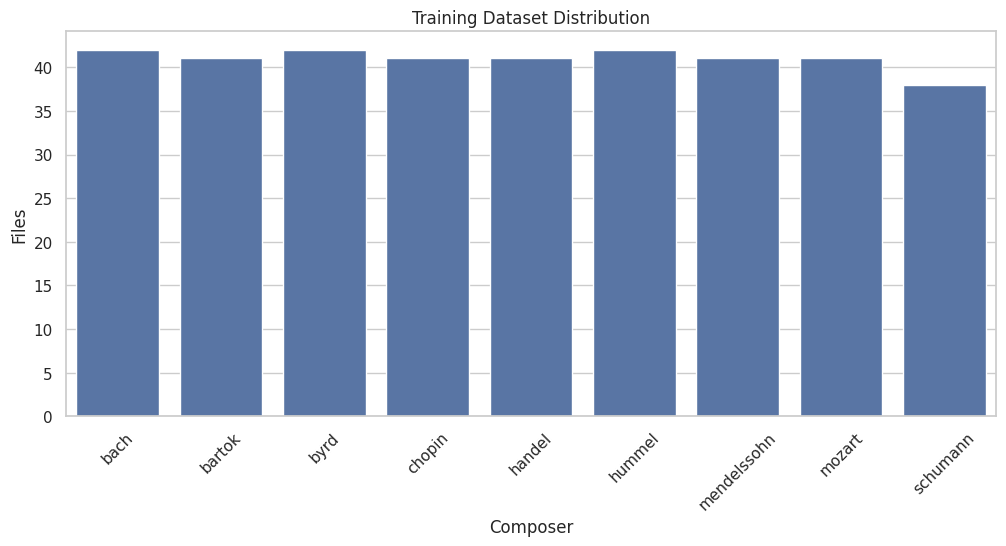

In [ ]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=train_stats,
    x="Composer",
    y="Files"
)

plt.title("Training Dataset Distribution")
plt.xticks(rotation=45)
plt.show()

# Musical Feature Extraction

Raw MIDI files cannot be directly used by machine learning algorithms.

Therefore, we extract a set of descriptive musical features including:

- Duration
- Tempo
- Number of Notes
- Average Pitch
- Average Velocity
- Average Note Duration
- Note Density
- Pitch Entropy

These engineered features summarize the musical characteristics of each composition.

In [ ]:
def extract_features(file_path, composer):

    from scipy.stats import entropy # Added missing import

    try:
        midi = pretty_midi.PrettyMIDI(file_path)

        notes = []

        for instrument in midi.instruments:
            if not instrument.is_drum:
                notes.extend(instrument.notes)

        if len(notes) == 0:
            return None

        # -------------------------------
        # Basic Information
        # -------------------------------
        duration = midi.get_end_time()

        try:
            tempo = midi.estimate_tempo()
        except:
            tempo = 120

        num_instruments = len(midi.instruments)

        time_signature = (
            midi.time_signature_changes[0].numerator
            if len(midi.time_signature_changes) > 0
            else 4
        )

        key_signature = (
            midi.key_signature_changes[0].key_number
            if len(midi.key_signature_changes) > 0
            else -1
        )

        # -------------------------------
        # Note Statistics
        # -------------------------------
        pitches = np.array([n.pitch for n in notes])


        velocities = np.array([n.velocity for n in notes])

        durations = np.array([
            n.end - n.start
            for n in notes
        ])

        starts = np.array([
            n.start
            for n in notes
        ])

        starts.sort()

        # -------------------------------
        # Rhythm Features
        # -------------------------------
        if len(starts) > 1:
            ioi = np.diff(starts)
        else:
            ioi = np.array([0])

        notes_per_second = len(notes) / duration if duration > 0 else 0

        # -------------------------------
        # Pitch Class Histogram
        # -------------------------------
        pitch_hist = np.zeros(12)

        for p in pitches:
            pitch_hist[p % 12] += 1

        pitch_hist = pitch_hist / pitch_hist.sum()

        pitch_entropy = entropy(
            pitch_hist + 1e-10,
            base=2
        )

        # -------------------------------
        # Chord Estimation
        # -------------------------------
        chord_sizes = []

        rounded = {}

        for n in notes:
            t = round(n.start, 2)

            if t not in rounded:
                rounded[t] = []

            rounded[t].append(n.pitch)

        for chord in rounded.values():
            if len(chord) >= 2:
                chord_sizes.append(len(chord))

        if len(chord_sizes) == 0:
            chord_sizes = [1]
        note_density = len(notes) / duration
        total_note_time = durations.sum()

        silence_ratio = max(
            0,
            1 - total_note_time / duration
        )
        sorted_pitches = pitches

        intervals = np.diff(sorted_pitches)

        if len(intervals) == 0:
            intervals = np.array([0])
        rhythm_entropy = entropy(
            np.histogram(ioi, bins=20)[0] + 1,
            base=2
        )
        polyphony = np.mean(chord_sizes)
        programs = [
            instrument.program
            for instrument in midi.instruments
        ]
        Unique_Programs = len(set(programs))
        velocity_entropy = entropy(
            np.histogram(
                velocities,
                bins=20
            )[0] + 1,
            base=2
        )
        duration_entropy = entropy(
            np.histogram(
                durations,
                bins=20
            )[0] + 1,
            base=2
        )
        if tempo < 80:
            tempo_group = 0
        elif tempo < 120:
            tempo_group = 1
        else:
            tempo_group = 2
        # -------------------------------
        # Feature Dictionary
        # -------------------------------
        features = {

            "Filename": os.path.basename(file_path),
            "Composer": composer,

            "Duration": duration,
            "Tempo": tempo,
            "Num_Instruments": num_instruments,
            "Time_Signature": time_signature,
            "Key_Signature": key_signature,

            "Total_Notes": len(notes),

            "Pitch_Min": pitches.min(),
            "Pitch_Max": pitches.max(),
            "Pitch_Mean": pitches.mean(),
            "Pitch_STD": pitches.std(),
            "Pitch_Range": pitches.max() - pitches.min(),

            "Duration_Min": durations.min(),
            "Duration_Max": durations.max(),
            "Duration_Mean": durations.mean(),
            "Duration_STD": durations.std(),

            "Velocity_Min": velocities.min(),
            "Velocity_Max": velocities.max(),
            "Velocity_Mean": velocities.mean(),
            "Velocity_STD": velocities.std(),

            "Notes_Per_Second": notes_per_second,

            "IOI_Mean": ioi.mean(),
            "IOI_STD": ioi.std(),

            "Num_Chords": len(chord_sizes),
            "Mean_Chord_Size": np.mean(chord_sizes),
            "Max_Chord_Size": np.max(chord_sizes),
            "Pitch_Entropy": pitch_entropy,

            "Note_Density": note_density,

            "Silence_Ratio": silence_ratio,

            "Interval_Mean": intervals.mean(),
            "Interval_STD": intervals.std(),
            "Interval_Min": intervals.min(),
            "Interval_Max": intervals.max(),

            "Rhythm_Entropy": rhythm_entropy,

            "Polyphony": polyphony,

            "Unique_Programs": len(set(programs)),

            "Velocity_Entropy": velocity_entropy,

            "Duration_Entropy": duration_entropy,

            "Tempo_Group": tempo_group
        }

        # Add Pitch Class Histogram
        for i in range(12):
            features[f"PitchClass_{i}"] = pitch_hist[i]

        return features

    except Exception as e:
        print(f"Error: {file_path}")
        return None

In [ ]:
def create_feature_dataset(folder):

    data = []

    composers = sorted([
        d for d in os.listdir(folder)
        if os.path.isdir(os.path.join(folder, d))
    ])

    for composer in composers:

        composer_path = os.path.join(folder, composer)

        print(f"Processing {composer}...")

        for file in os.listdir(composer_path):

            if file.lower().endswith((".mid", ".midi")):

                feature = extract_features(
                    os.path.join(composer_path, file),
                    composer
                )

                if feature is not None:
                    data.append(feature)

    return pd.DataFrame(data)

# Build the Feature Dataset

Each MIDI file is processed individually to extract a collection of handcrafted musical features.

The resulting feature vector represents a single composition and serves as the input for all Machine Learning models.

Each row in the dataset corresponds to:

- One MIDI composition
- One composer label
- Multiple numerical musical descriptors

In [ ]:
# ============================================================
# Create Feature Dataset
# ============================================================

train_df = create_feature_dataset(train_dir)
val_df = create_feature_dataset(val_dir)
test_df = create_feature_dataset(test_dir)

print("=" * 50)
print("Dataset Creation Complete")
print("=" * 50)

print(f"Training Samples   : {len(train_df)}")
print(f"Validation Samples : {len(val_df)}")
print(f"Testing Samples    : {len(test_df)}")

Processing bach...
Processing bartok...
Processing byrd...
Processing chopin...
Processing handel...
Processing hummel...
Processing mendelssohn...
Processing mozart...
Processing schumann...
Processing bach...
Processing bartok...
Processing byrd...
Processing chopin...
Processing handel...
Processing hummel...
Processing mendelssohn...
Processing mozart...
Processing schumann...
Processing bach...
Processing bartok...
Processing byrd...
Processing chopin...
Processing handel...
Processing hummel...
Processing mendelssohn...
Processing mozart...
Processing schumann...
Dataset Creation Complete
Training Samples   : 369
Validation Samples : 35
Testing Samples    : 35


# Preview the Dataset

Before performing any preprocessing, we inspect a few rows of the extracted dataset to verify that all musical features have been computed correctly.

In [ ]:
train_df.head()

,Filename,Composer,Duration,Tempo,Num_Instruments,Time_Signature,Key_Signature,Total_Notes,Pitch_Min,Pitch_Max,...,PitchClass_2,PitchClass_3,PitchClass_4,PitchClass_5,PitchClass_6,PitchClass_7,PitchClass_8,PitchClass_9,PitchClass_10,PitchClass_11
0,bach364.mid,bach,90.243490,209.424982,11,4,-1,702,36,84,...,0.121083,0.037037,0.158120,0.000000,0.121083,0.133903,0.002849,0.092593,0.007123,0.178063
1,bach370.mid,bach,79.886719,256.124254,12,4,-1,558,37,84,...,0.132616,0.008961,0.130824,0.019713,0.161290,0.080645,0.051971,0.123656,0.026882,0.141577
2,bach361.mid,bach,91.352865,208.722343,11,4,-1,618,36,82,...,0.144013,0.132686,0.012945,0.147249,0.004854,0.121359,0.033981,0.092233,0.152104,0.004854
3,bach389.mid,bach,760.005208,248.196195,12,4,-1,5313,36,84,...,0.154903,0.071899,0.049125,0.090156,0.044231,0.155844,0.019951,0.127800,0.122153,0.023339
4,bach363.mid,bach,106.638021,193.312132,12,4,-1,672,37,83,...,0.139881,0.007440,0.129464,0.001488,0.175595,0.074405,0.023810,0.101190,0.022321,0.209821


# Dataset Dimensions

Understanding the size of the dataset helps verify that the feature extraction process completed successfully.

In [ ]:
print(f"Training Shape   : {train_df.shape}")
print(f"Validation Shape : {val_df.shape}")
print(f"Testing Shape    : {test_df.shape}")

Training Shape   : (369, 52)
Validation Shape : (35, 52)
Testing Shape    : (35, 52)


# Dataset Information

The following summary provides:

- Data types
- Number of observations
- Non-null values
- Memory usage

This helps identify missing values and datatype inconsistencies.

# Statistical Summary

Descriptive statistics provide insight into the distribution of each numerical feature.

Metrics include:

- Mean
- Standard Deviation
- Minimum
- Maximum
- Quartiles

In [ ]:
print("Training Dataset")
display(train_df.info())

print("\nSummary Statistics")
display(train_df.describe())

Training Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 369 entries, 0 to 368
Data columns (total 52 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Filename          369 non-null    object 
 1   Composer          369 non-null    object 
 2   Duration          369 non-null    float64
 3   Tempo             369 non-null    float64
 4   Num_Instruments   369 non-null    int64  
 5   Time_Signature    369 non-null    int64  
 6   Key_Signature     369 non-null    int64  
 7   Total_Notes       369 non-null    int64  
 8   Pitch_Min         369 non-null    int64  
 9   Pitch_Max         369 non-null    int64  
 10  Pitch_Mean        369 non-null    float64
 11  Pitch_STD         369 non-null    float64
 12  Pitch_Range       369 non-null    int64  
 13  Duration_Min      369 non-null    float64
 14  Duration_Max      369 non-null    float64
 15  Duration_Mean     369 non-null    float64
 16  Duration_STD      369 non-n

None


Summary Statistics


,Duration,Tempo,Num_Instruments,Time_Signature,Key_Signature,Total_Notes,Pitch_Min,Pitch_Max,Pitch_Mean,Pitch_STD,...,PitchClass_2,PitchClass_3,PitchClass_4,PitchClass_5,PitchClass_6,PitchClass_7,PitchClass_8,PitchClass_9,PitchClass_10,PitchClass_11
count,369.000000,369.000000,369.000000,369.000000,369.000000,369.000000,369.000000,369.000000,369.000000,369.000000,...,369.000000,369.000000,369.000000,369.000000,369.000000,369.000000,369.000000,369.000000,369.000000,369.000000
mean,322.567476,197.975127,6.810298,3.712737,0.880759,3998.398374,32.330623,88.016260,63.448082,10.895393,...,0.118145,0.050113,0.105296,0.074059,0.066854,0.115722,0.051800,0.115213,0.056418,0.088608
std,302.325716,37.490798,6.824413,1.153386,3.922744,4878.354376,6.638504,7.985364,3.048436,1.916595,...,0.060663,0.052415,0.059006,0.055116,0.050437,0.061338,0.053821,0.057296,0.054513,0.059489
min,26.690451,70.272438,1.000000,1.000000,-1.000000,109.000000,0.000000,69.000000,52.663793,2.283740,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,122.487500,176.512456,1.000000,4.000000,-1.000000,971.000000,28.000000,82.000000,61.635609,9.675902,...,0.079096,0.007321,0.062336,0.019052,0.025194,0.074973,0.008906,0.074106,0.008977,0.038611
50%,227.483502,200.267451,4.000000,4.000000,-1.000000,2186.000000,31.000000,86.000000,63.502412,10.978492,...,0.118537,0.030194,0.105007,0.073673,0.054064,0.116965,0.032200,0.114973,0.038168,0.084193
75%,428.860438,224.628301,11.000000,4.000000,0.000000,4935.000000,36.000000,93.000000,65.354492,12.188466,...,0.158514,0.082324,0.140652,0.109022,0.100000,0.159091,0.082422,0.157356,0.089444,0.122846
max,2130.652310,283.645377,50.000000,12.000000,23.000000,31879.000000,57.000000,119.000000,72.311264,17.068614,...,0.301570,0.237960,0.327931,0.246539,0.241641,0.261185,0.302583,0.275229,0.230511,0.322196


In [ ]:
display(train_df.describe().T.style.background_gradient(cmap="Blues"))

,count,mean,std,min,25%,50%,75%,max
Duration,369.000000,322.567476,302.325716,26.690451,122.487500,227.483502,428.860438,2130.652310
Tempo,369.000000,197.975127,37.490798,70.272438,176.512456,200.267451,224.628301,283.645377
Num_Instruments,369.000000,6.810298,6.824413,1.000000,1.000000,4.000000,11.000000,50.000000
Time_Signature,369.000000,3.712737,1.153386,1.000000,4.000000,4.000000,4.000000,12.000000
Key_Signature,369.000000,0.880759,3.922744,-1.000000,-1.000000,-1.000000,0.000000,23.000000
Total_Notes,369.000000,3998.398374,4878.354376,109.000000,971.000000,2186.000000,4935.000000,31879.000000
Pitch_Min,369.000000,32.330623,6.638504,0.000000,28.000000,31.000000,36.000000,57.000000
Pitch_Max,369.000000,88.016260,7.985364,69.000000,82.000000,86.000000,93.000000,119.000000
Pitch_Mean,369.000000,63.448082,3.048436,52.663793,61.635609,63.502412,65.354492,72.311264
Pitch_STD,369.000000,10.895393,1.916595,2.283740,9.675902,10.978492,12.188466,17.068614


# Missing Value Analysis

Missing values can negatively affect model performance.

The following analysis verifies whether any extracted feature contains missing observations.

In [ ]:
missing = train_df.isnull().sum()

missing = missing[missing > 0]

if len(missing) == 0:
    print("No missing values found.")
else:
    display(missing)

No missing values found.


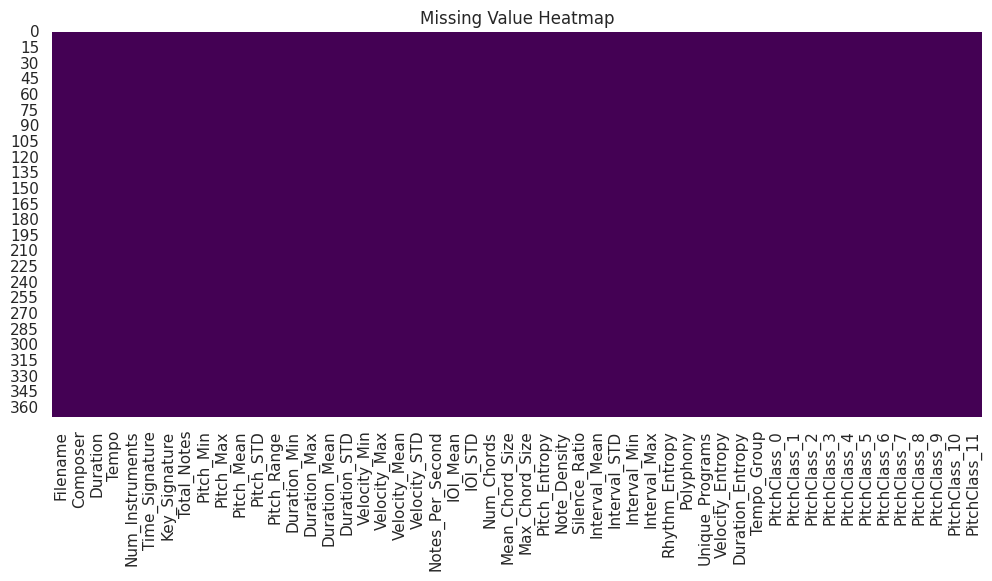

In [ ]:
plt.figure(figsize=(12,5))

sns.heatmap(
    train_df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Value Heatmap")
plt.show()

# Duplicate Sample Analysis

Duplicate observations can introduce bias during model training.

We verify that each extracted feature vector represents a unique musical composition.

In [ ]:
duplicates = train_df.duplicated().sum()

print(f"Duplicate Samples : {duplicates}")

Duplicate Samples : 0


# Composer Distribution

Class balance is an important factor in supervised learning.

The following visualizations show the number of compositions available for each composer.

In [ ]:
composer_counts = train_df["Composer"].value_counts()

display(composer_counts)

,count
Composer,
bach,42
byrd,42
hummel,42
chopin,41
bartok,41
handel,41
mendelssohn,41
mozart,41
schumann,38


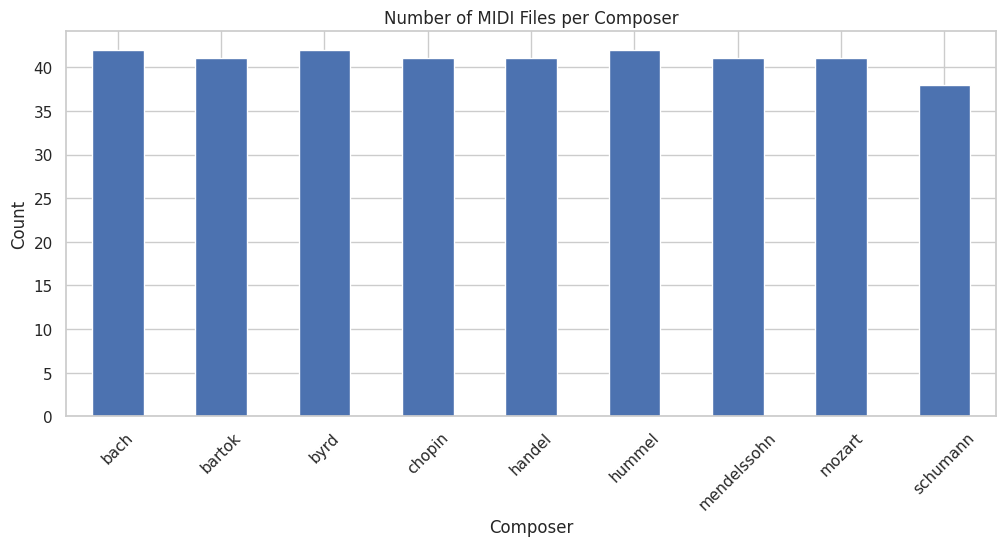

In [ ]:
plt.figure(figsize=(12,5))

train_df["Composer"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Number of MIDI Files per Composer")
plt.xlabel("Composer")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

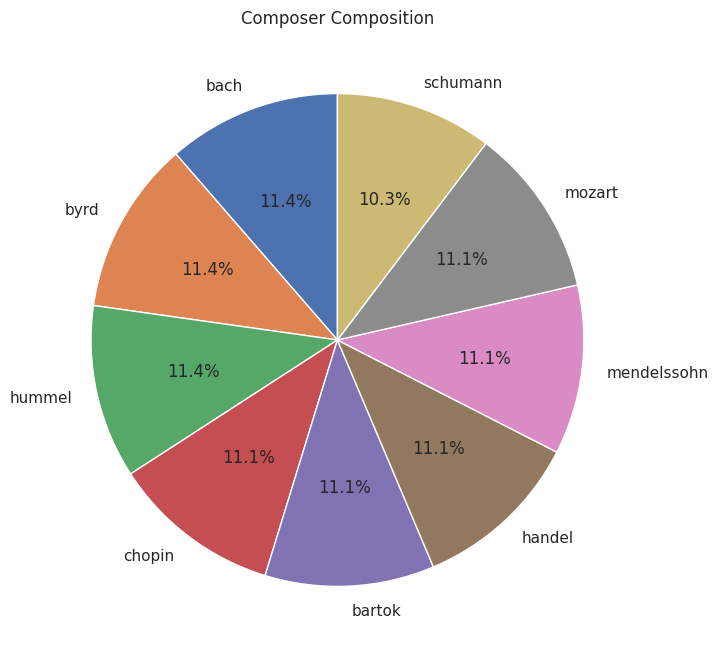

In [ ]:
plt.figure(figsize=(8,8))

composer_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")
plt.title("Composer Composition")
plt.show()

# Numerical Feature Distribution

Each handcrafted feature captures a different aspect of musical composition.

Visualizing their distributions helps identify:

- Skewed variables
- Multi-modal distributions
- Outliers
- Feature ranges

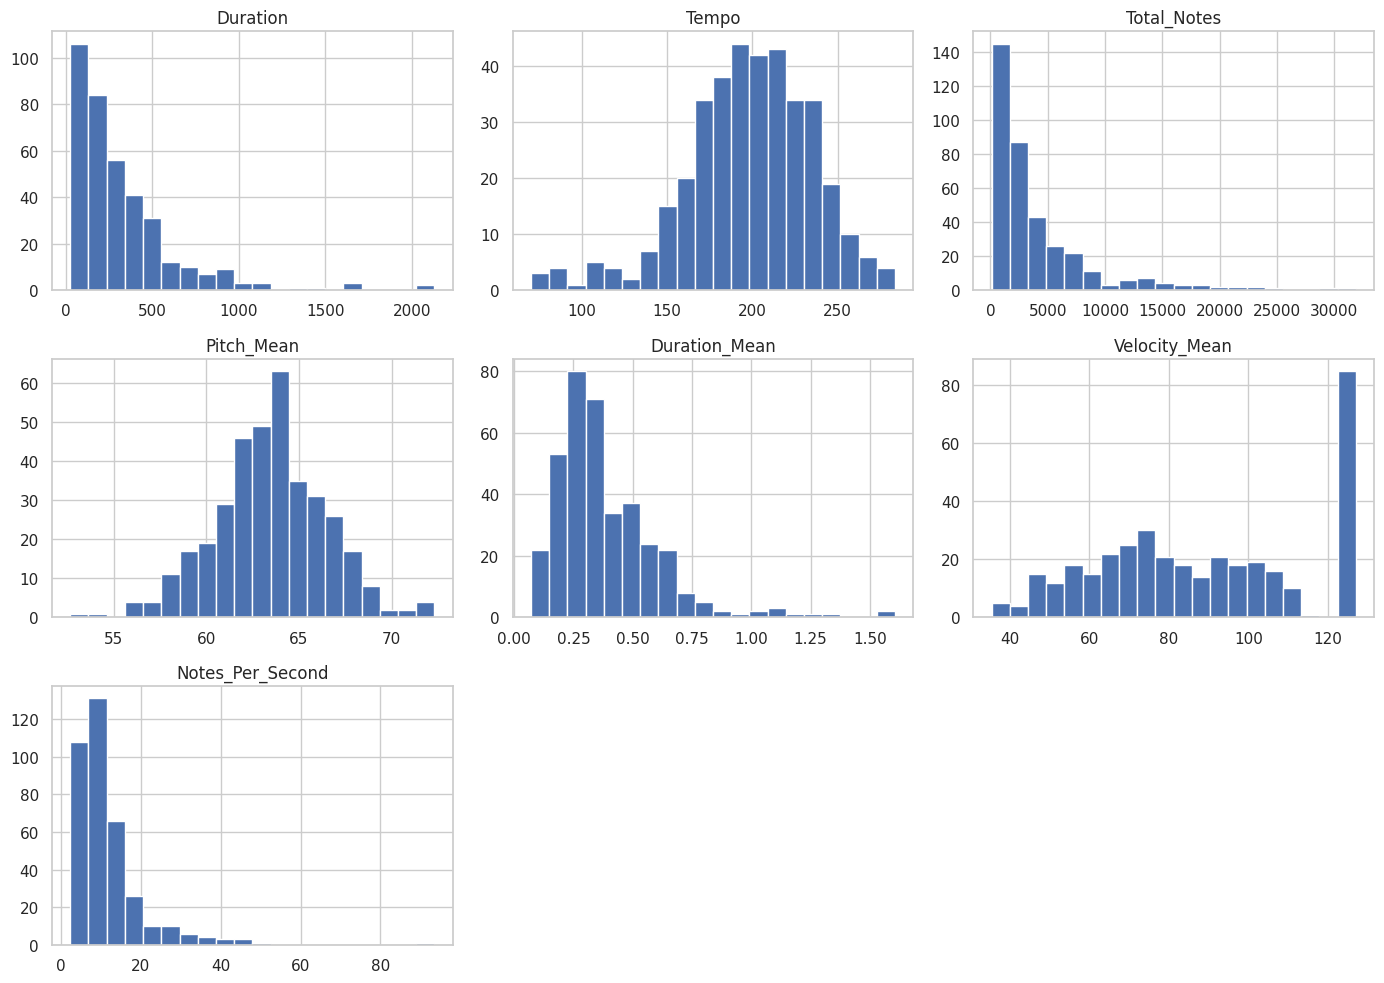

In [ ]:
numeric_cols = [
    "Duration",
    "Tempo",
    "Total_Notes",
    "Pitch_Mean",
    "Duration_Mean",
    "Velocity_Mean",
    "Notes_Per_Second"
]

train_df[numeric_cols].hist(
    figsize=(14,10),
    bins=20
)

plt.tight_layout()
plt.show()

# Feature Correlation Analysis

Correlation analysis reveals relationships among musical features.

Highly correlated variables may provide redundant information, while independent features often contribute unique predictive power.

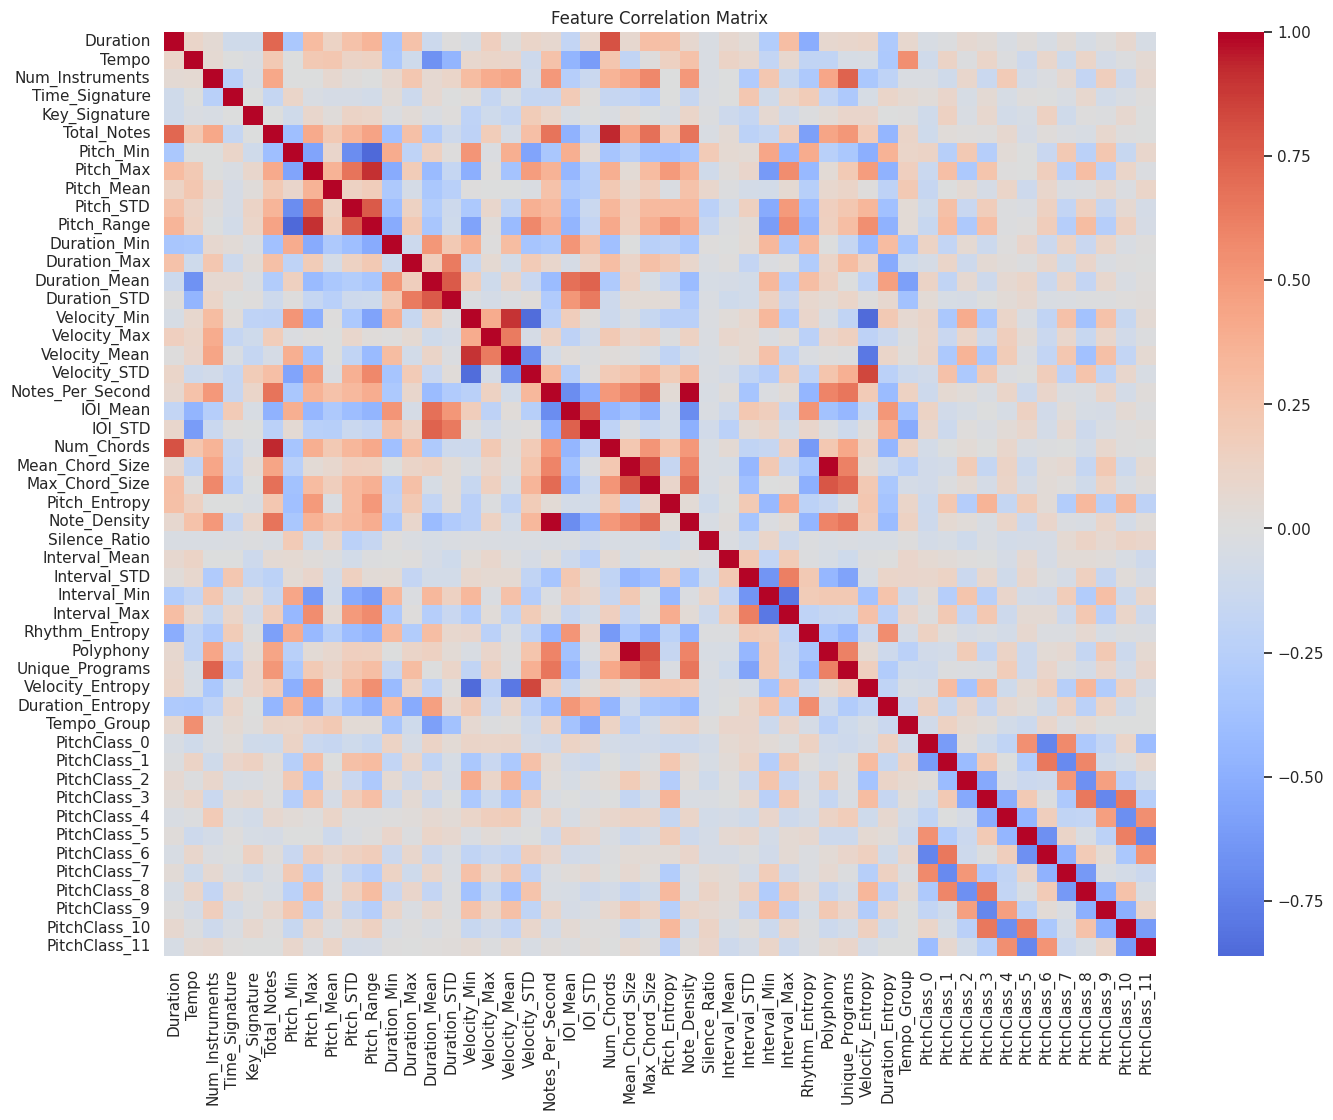

In [ ]:
numeric_df = train_df.select_dtypes(include=np.number)

plt.figure(figsize=(16,12))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.show()

# Pairwise Relationships

Pairwise plots illustrate how selected musical features vary across different composers.

These visualizations help determine whether the classes exhibit natural separation in the feature space.

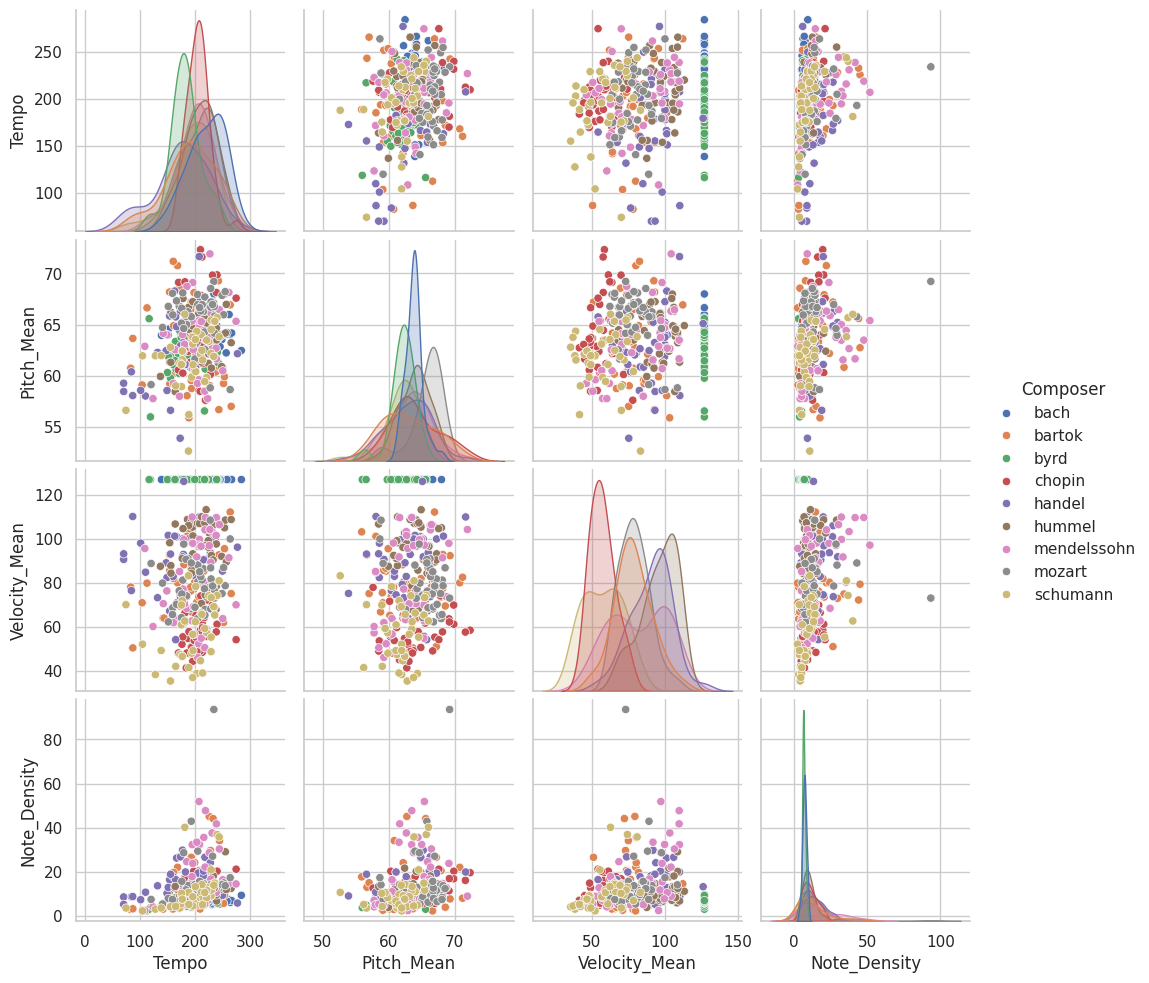

In [ ]:
important = [
    "Tempo",
    "Pitch_Mean",
    "Velocity_Mean",
    "Note_Density",
    "Composer"
]

sns.pairplot(
    train_df[important],
    hue="Composer",
    diag_kind="kde"
)

# Outlier Detection

Boxplots provide a robust visualization of feature spread and potential outliers.

Extreme values may represent unique musical styles or anomalies in feature extraction.

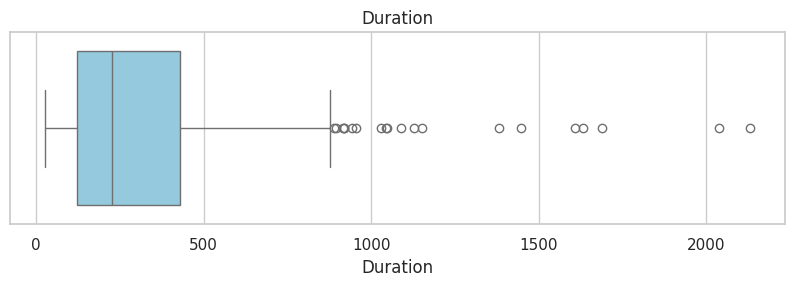

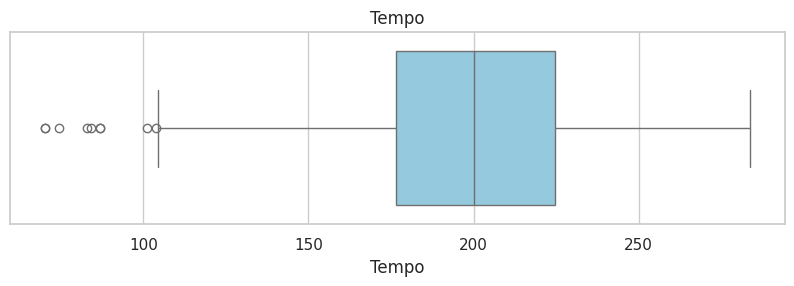

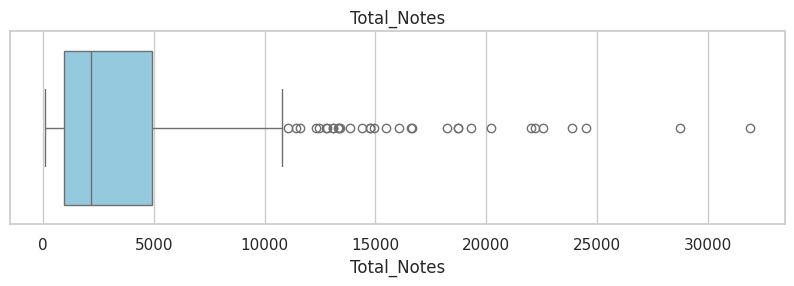

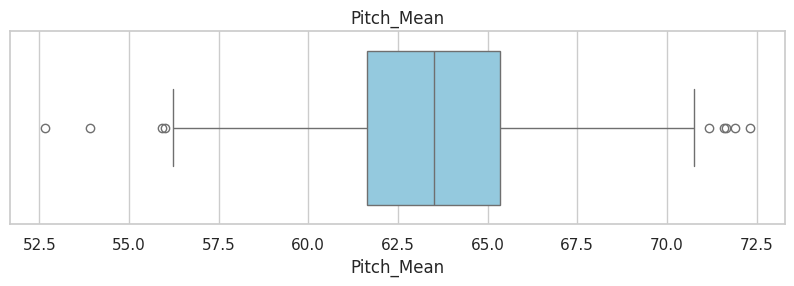

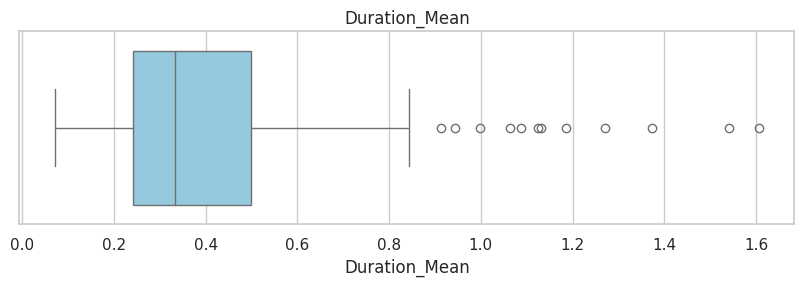

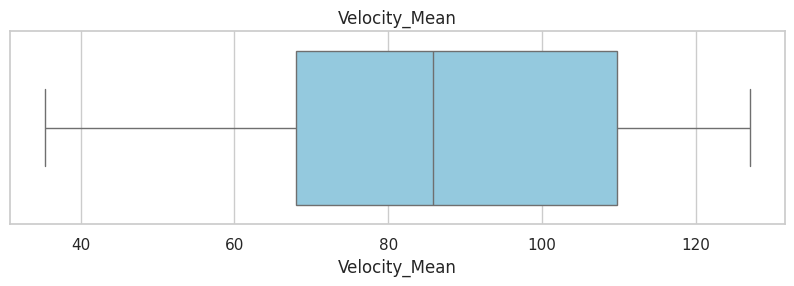

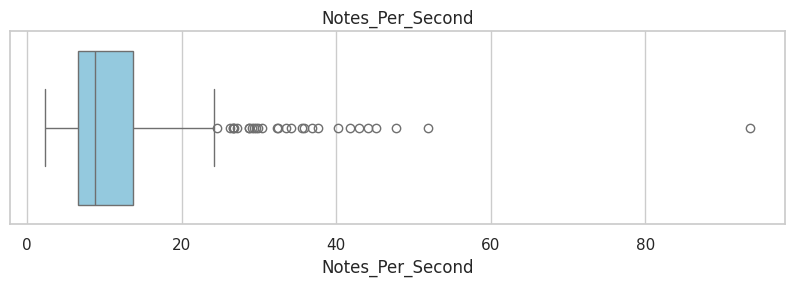

In [ ]:
for feature in numeric_cols:

    plt.figure(figsize=(10,2.5))

    sns.boxplot(
        x=train_df[feature],
        color="skyblue"
    )

    plt.title(feature)

    plt.show()

# Data Preprocessing

Machine Learning algorithms require numerical, standardized, and clean data.

In this section we prepare the extracted musical features by:

- Separating features and target labels
- Encoding categorical labels
- Standardizing numerical features
- Creating train, validation, and test datasets

This ensures that every model receives consistent input data.

In [ ]:
# ============================================================
# Separate Features and Labels
# ============================================================

X_train = train_df.drop(columns=["Composer", "Filename"])
y_train = train_df["Composer"]

X_val = val_df.drop(columns=["Composer", "Filename"])
y_val = val_df["Composer"]

X_test = test_df.drop(columns=["Composer", "Filename"])
y_test = test_df["Composer"]

print("Training Features :", X_train.shape)
print("Validation Features :", X_val.shape)
print("Testing Features :", X_test.shape)

Training Features : (369, 50)
Validation Features : (35, 50)
Testing Features : (35, 50)


# Label Encoding

Machine Learning models require numerical target labels.

Each composer name is converted into a unique integer while preserving the mapping between labels and classes.

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_train_enc = encoder.fit_transform(y_train)
y_val_enc = encoder.transform(y_val)
y_test_enc = encoder.transform(y_test)

label_mapping = pd.DataFrame({
    "Composer": encoder.classes_,
    "Encoded Label": range(len(encoder.classes_))
})

display(label_mapping)

,Composer,Encoded Label
0,bach,0
1,bartok,1
2,byrd,2
3,chopin,3
4,handel,4
5,hummel,5
6,mendelssohn,6
7,mozart,7
8,schumann,8


# Feature Scaling

Musical features vary significantly in magnitude.

For example:

- Tempo may range between 60–220 BPM.
- Note density may be below 10.
- Pitch values are typically between 20 and 100.

Standardization ensures that all features contribute equally during model training.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling Completed")

Scaling Completed


# Feature Distribution After Scaling

The standardized features should now exhibit approximately zero mean and unit variance.

This visualization verifies the effectiveness of the scaling process.

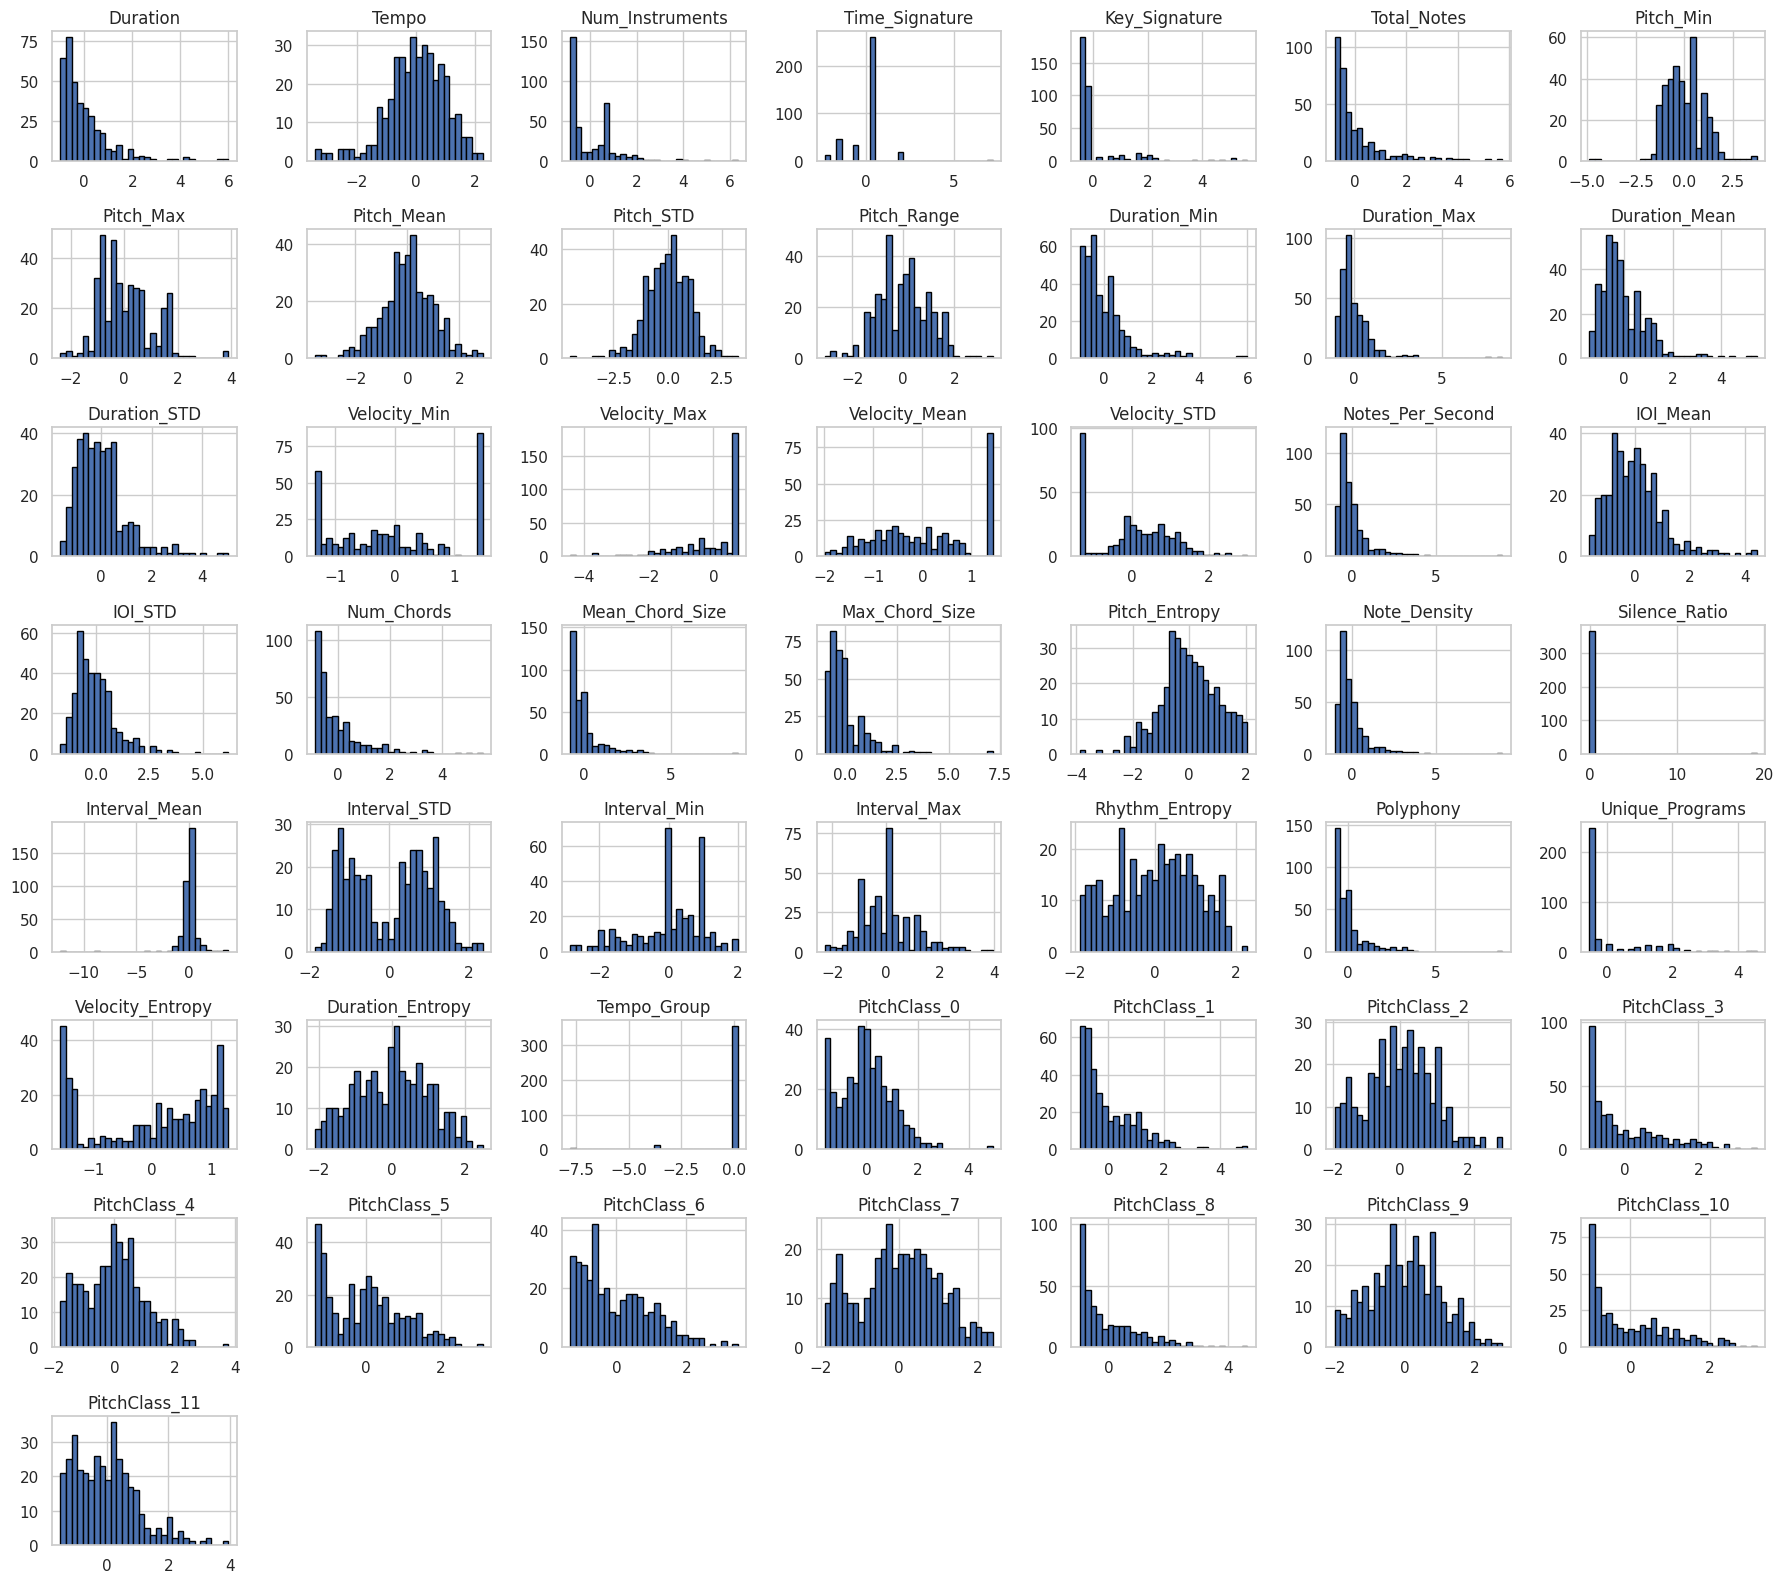

In [ ]:
scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

scaled_df.hist(
    figsize=(18,16),
    bins=30,
    edgecolor="black"
)

plt.tight_layout()
plt.show()

# Principal Component Analysis (Optional Visualization)

Although the complete feature set is retained for training, Principal Component Analysis (PCA) is used to visualize the separability of composers in a lower-dimensional feature space.

PCA reduces the feature space while preserving as much variance as possible.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "Composer": y_train.values
})

display(pca_df.head())

,PC1,PC2,Composer
0,-2.551957,0.628873,bach
1,-2.194766,-0.004351,bach
2,-2.943978,-0.777657,bach
3,-1.019406,0.677632,bach
4,-2.587308,0.665989,bach


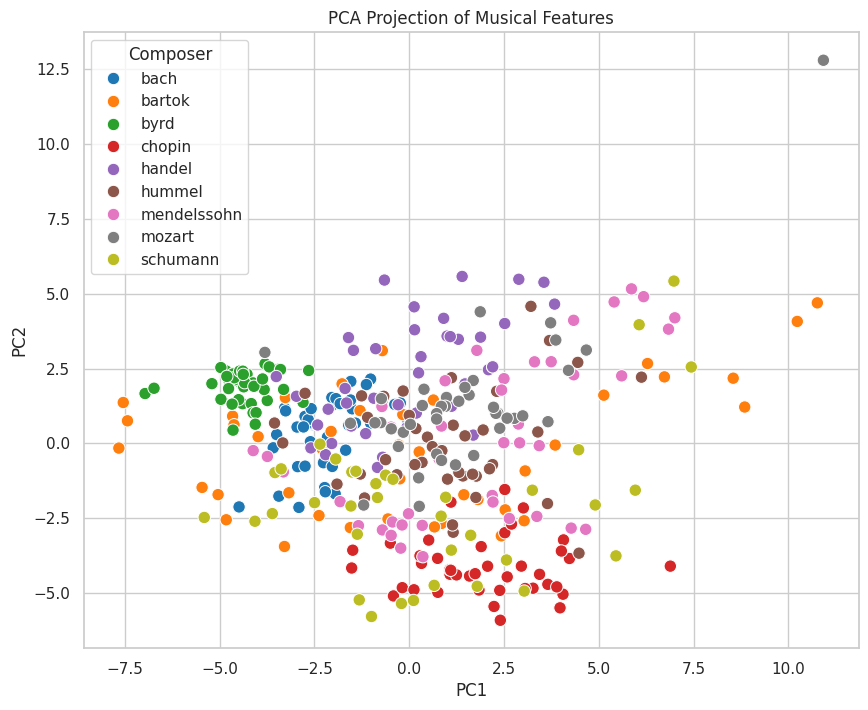

In [ ]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Composer",
    palette="tab10",
    s=80
)

plt.title("PCA Projection of Musical Features")
plt.show()

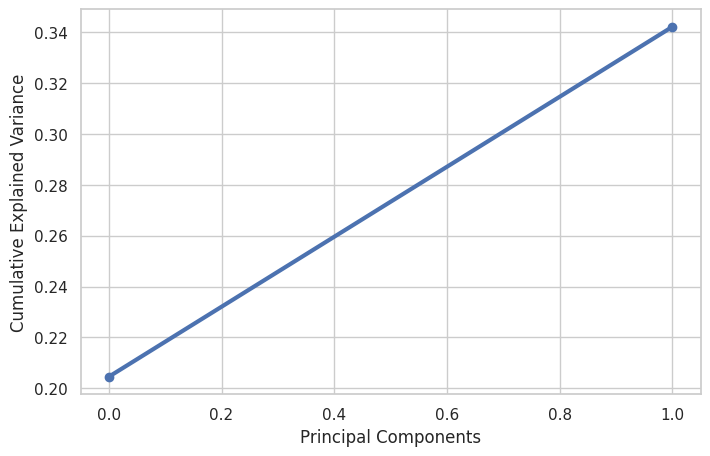

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    marker="o",
    linewidth=3
)

plt.xlabel("Principal Components")
plt.ylabel("Cumulative Explained Variance")

plt.grid(True)

plt.show()

# Baseline Machine Learning Models

Before developing deep learning architectures, several classical Machine Learning algorithms are evaluated.

These models establish strong performance baselines for comparison.

The evaluated algorithms include:

- Logistic Regression
- Random Forest
- XGBoost

# Logistic Regression

Logistic Regression is a simple linear classifier that models the probability of each composer using the softmax function.

Although computationally efficient, it assumes linear decision boundaries and therefore serves as a useful baseline model.

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred, average="weighted"))
print("Recall   :", recall_score(y_test, lr_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, lr_pred, average="weighted"))

Accuracy : 0.8285714285714286
Precision: 0.8304761904761905
Recall   : 0.8285714285714286
F1 Score : 0.8235827664399092


In [ ]:
print("\nClassification Report\n")
print(classification_report(
    y_test,
    lr_pred,
    target_names=encoder.classes_
))


Classification Report

              precision    recall  f1-score   support

        bach       1.00      1.00      1.00         4
      bartok       1.00      0.75      0.86         4
        byrd       1.00      1.00      1.00         4
      chopin       0.75      0.75      0.75         4
      handel       0.80      1.00      0.89         4
      hummel       0.80      1.00      0.89         4
 mendelssohn       0.67      0.50      0.57         4
      mozart       1.00      1.00      1.00         4
    schumann       0.33      0.33      0.33         3

    accuracy                           0.83        35
   macro avg       0.82      0.81      0.81        35
weighted avg       0.83      0.83      0.82        35



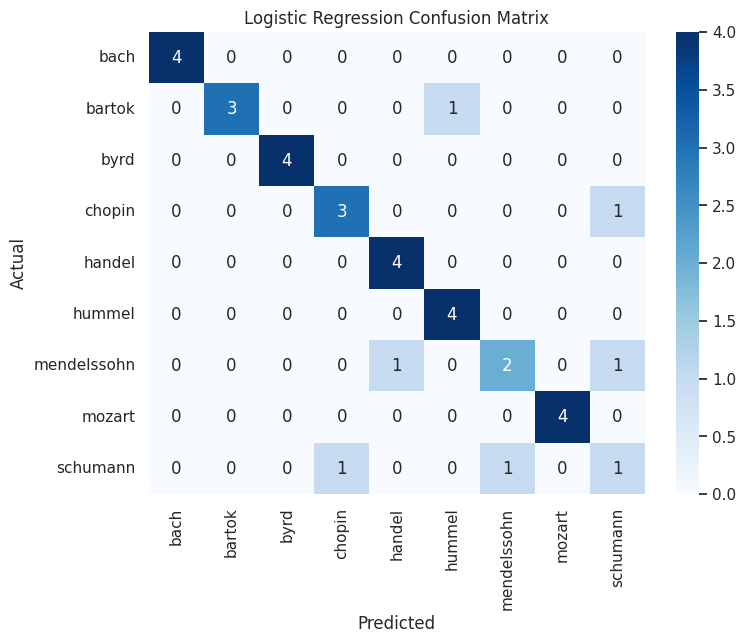

In [ ]:
cm = confusion_matrix(
    y_test_enc,
    encoder.transform(lr_pred)
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
lr_results = pd.DataFrame(
    classification_report(
        y_test_enc,
        encoder.transform(lr_pred),
        output_dict=True
    )
).transpose()

display(lr_results)

,precision,recall,f1-score,support
0,1.000000,1.000000,1.000000,4.000000
1,1.000000,0.750000,0.857143,4.000000
2,1.000000,1.000000,1.000000,4.000000
3,0.750000,0.750000,0.750000,4.000000
4,0.800000,1.000000,0.888889,4.000000
5,0.800000,1.000000,0.888889,4.000000
6,0.666667,0.500000,0.571429,4.000000
7,1.000000,1.000000,1.000000,4.000000
8,0.333333,0.333333,0.333333,3.000000
accuracy,0.828571,0.828571,0.828571,0.828571


# Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve predictive performance and reduce overfitting.

It is particularly effective when working with nonlinear relationships between handcrafted musical features.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred, average="weighted"))
print("Recall   :", recall_score(y_test, rf_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, rf_pred, average="weighted"))

Accuracy : 0.8571428571428571
Precision: 0.8081632653061224
Recall   : 0.8571428571428571
F1 Score : 0.825974025974026


In [ ]:
print("\nClassification Report\n")
print(classification_report(
    y_test,
    rf_pred,
    target_names=encoder.classes_
))


Classification Report

              precision    recall  f1-score   support

        bach       1.00      1.00      1.00         4
      bartok       0.75      0.75      0.75         4
        byrd       1.00      1.00      1.00         4
      chopin       0.57      1.00      0.73         4
      handel       1.00      1.00      1.00         4
      hummel       0.75      0.75      0.75         4
 mendelssohn       1.00      1.00      1.00         4
      mozart       1.00      1.00      1.00         4
    schumann       0.00      0.00      0.00         3

    accuracy                           0.86        35
   macro avg       0.79      0.83      0.80        35
weighted avg       0.81      0.86      0.83        35



In [ ]:
rf_results = pd.DataFrame(
    classification_report(
        y_test_enc,
        encoder.transform(rf_pred),
        output_dict=True
    )
).transpose()

display(rf_results)

,precision,recall,f1-score,support
0,1.000000,1.000000,1.000000,4.000000
1,0.750000,0.750000,0.750000,4.000000
2,1.000000,1.000000,1.000000,4.000000
3,0.571429,1.000000,0.727273,4.000000
4,1.000000,1.000000,1.000000,4.000000
5,0.750000,0.750000,0.750000,4.000000
6,1.000000,1.000000,1.000000,4.000000
7,1.000000,1.000000,1.000000,4.000000
8,0.000000,0.000000,0.000000,3.000000
accuracy,0.857143,0.857143,0.857143,0.857143


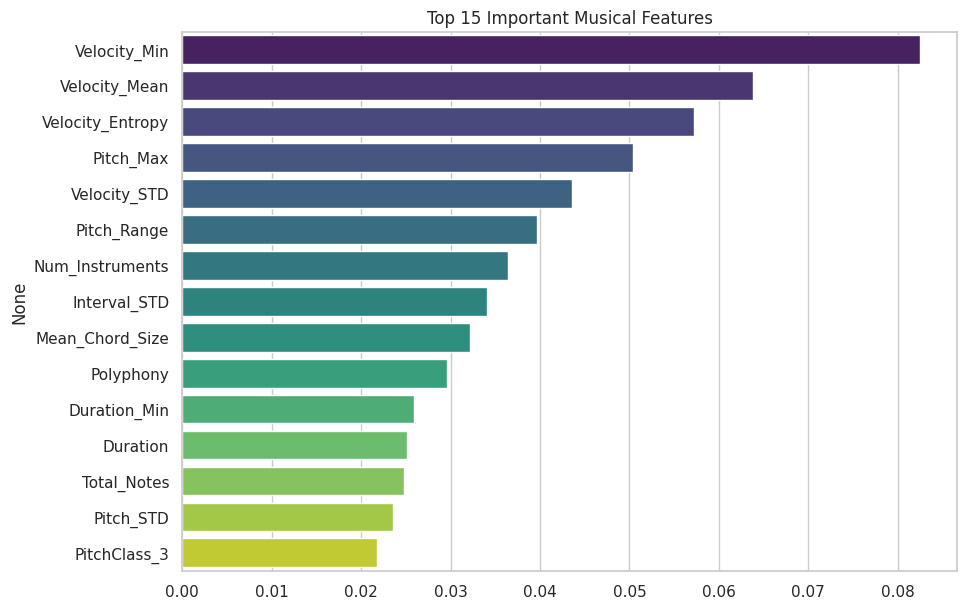

In [ ]:
importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,7))

sns.barplot(
    x=importance.values[:15],
    y=importance.index[:15],
    palette="viridis"
)

plt.title("Top 15 Important Musical Features")

plt.show()

# XGBoost Classifier

Extreme Gradient Boosting (XGBoost) is one of the most powerful ensemble learning techniques.

It sequentially builds decision trees by correcting the errors made by previous trees, often achieving state-of-the-art performance on structured datasets.

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(X_train, y_train_enc)

xgb_pred = xgb.predict(X_test)

print("Accuracy :", accuracy_score(y_test_enc, xgb_pred))
print("Precision:", precision_score(y_test_enc, xgb_pred, average="weighted"))
print("Recall   :", recall_score(y_test_enc, xgb_pred, average="weighted"))
print("F1 Score :", f1_score(y_test_enc, xgb_pred, average="weighted"))

Accuracy : 0.8571428571428571
Precision: 0.86
Recall   : 0.8571428571428571
F1 Score : 0.8528798185941043


In [ ]:
print(classification_report(
    y_test_enc,
    xgb_pred,
    target_names=encoder.classes_
))

              precision    recall  f1-score   support

        bach       1.00      1.00      1.00         4
      bartok       0.80      1.00      0.89         4
        byrd       1.00      1.00      1.00         4
      chopin       0.75      0.75      0.75         4
      handel       1.00      0.75      0.86         4
      hummel       1.00      1.00      1.00         4
 mendelssohn       0.60      0.75      0.67         4
      mozart       1.00      1.00      1.00         4
    schumann       0.50      0.33      0.40         3

    accuracy                           0.86        35
   macro avg       0.85      0.84      0.84        35
weighted avg       0.86      0.86      0.85        35



In [ ]:
xgb_results = pd.DataFrame(
    classification_report(
        y_test_enc,
        xgb_pred,
        output_dict=True
    )
).transpose()

display(xgb_results)

,precision,recall,f1-score,support
0,1.000000,1.000000,1.000000,4.000000
1,0.800000,1.000000,0.888889,4.000000
2,1.000000,1.000000,1.000000,4.000000
3,0.750000,0.750000,0.750000,4.000000
4,1.000000,0.750000,0.857143,4.000000
5,1.000000,1.000000,1.000000,4.000000
6,0.600000,0.750000,0.666667,4.000000
7,1.000000,1.000000,1.000000,4.000000
8,0.500000,0.333333,0.400000,3.000000
accuracy,0.857143,0.857143,0.857143,0.857143


<Figure size 1000x800 with 0 Axes>

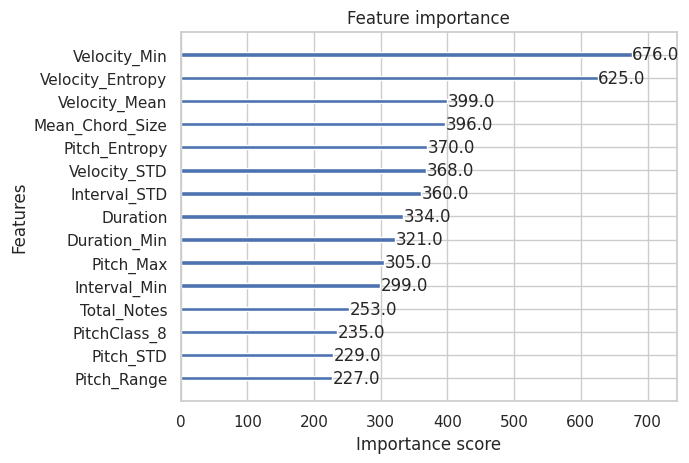

In [ ]:
from xgboost import plot_importance

plt.figure(figsize=(10,8))

plot_importance(
    xgb,
    max_num_features=15
)

plt.show()

# Machine Learning Model Comparison

To understand the relative strengths of each algorithm, we compare their performance using multiple evaluation metrics.

The following table summarizes:

- Accuracy
- Precision
- Recall
- F1-score

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test_enc, encoder.transform(lr_pred)),
        accuracy_score(y_test_enc, encoder.transform(rf_pred)),
        accuracy_score(y_test_enc, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test_enc, encoder.transform(lr_pred), average="weighted"),
        precision_score(y_test_enc, encoder.transform(rf_pred), average="weighted"),
        precision_score(y_test_enc, xgb_pred, average="weighted")
    ],
    "Recall": [
        recall_score(y_test_enc, encoder.transform(lr_pred), average="weighted"),
        recall_score(y_test_enc, encoder.transform(rf_pred), average="weighted"),
        recall_score(y_test_enc, xgb_pred, average="weighted")
    ],
    "F1 Score": [
        f1_score(y_test_enc, encoder.transform(lr_pred), average="weighted"),
        f1_score(y_test_enc, encoder.transform(rf_pred), average="weighted"),
        f1_score(y_test_enc, xgb_pred, average="weighted")
    ]
})

results.sort_values("Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
1,Random Forest,0.857143,0.808163,0.857143,0.825974
2,XGBoost,0.857143,0.860000,0.857143,0.852880
0,Logistic Regression,0.828571,0.830476,0.828571,0.823583


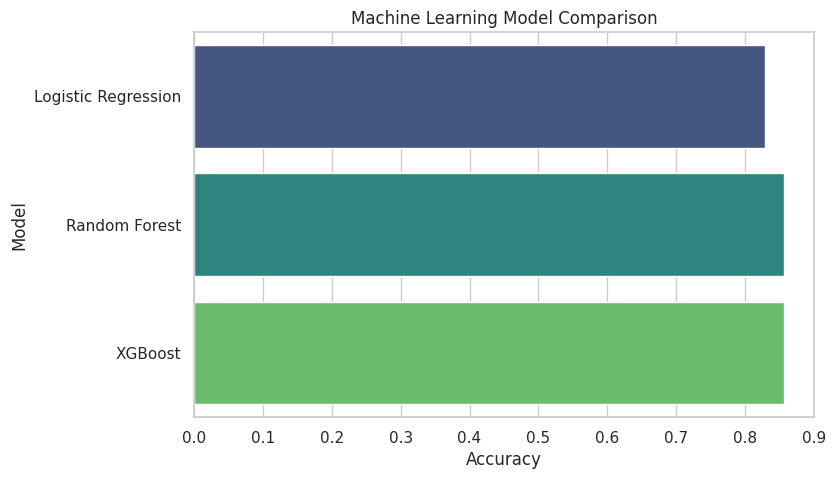

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Accuracy",
    y="Model",
    palette="viridis"
)

plt.title("Machine Learning Model Comparison")

plt.show()

# Hyperparameter Optimization using GridSearchCV

The performance of a Machine Learning model is heavily influenced by its hyperparameters.

Instead of manually selecting parameter values, we perform an exhaustive search over a predefined parameter space using **GridSearchCV**.

GridSearchCV evaluates every possible parameter combination through **k-fold cross-validation**, selecting the configuration that produces the best average validation performance.

### Advantages

- Eliminates manual trial-and-error
- Reduces overfitting through cross-validation
- Identifies the optimal parameter combination
- Improves model generalization

In [ ]:
from sklearn.model_selection import GridSearchCV

lr_params = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["lbfgs"],
    "max_iter": [5000]
}

lr_grid = GridSearchCV(
    LogisticRegression(),
    lr_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

lr_grid.fit(X_train_scaled, y_train)

print("Best Parameters:", lr_grid.best_params_)
print("Best CV Score:", lr_grid.best_score_)

Best Parameters: {'C': 0.1, 'max_iter': 5000, 'solver': 'lbfgs'}
Best CV Score: 0.788633839318771


In [ ]:
rf_params = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print(rf_grid.best_params_)
print(rf_grid.best_score_)

{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
0.8563495001851166


In [ ]:
xgb_params = {
    "n_estimators": [200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [4, 6, 8],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric="mlogloss"
    ),
    xgb_params,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train_enc)

print(xgb_grid.best_params_)
print(xgb_grid.best_score_)

{'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
0.829268292682927


# Cross-Validation Results

GridSearchCV stores the performance of every evaluated parameter combination.

Analyzing these results provides insight into the influence of different hyperparameters on model performance.

In [ ]:
best_lr = lr_grid.best_estimator_
best_rf = rf_grid.best_estimator_
best_xgb = xgb_grid.best_estimator_

models = {
    "Logistic Regression": (best_lr, X_test_scaled),
    "Random Forest": (best_rf, X_test),
    "XGBoost": (best_xgb, X_test)
}

results = []

for name, (model, X) in models.items():

    pred = model.predict(X)

    # Ensure predictions are numerical for consistency with y_test_enc
    if isinstance(pred[0], str):
        pred_enc = encoder.transform(pred)
    else:
        pred_enc = pred

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_enc, pred_enc),
        "Precision": precision_score(y_test_enc, pred_enc, average="weighted"),
        "Recall": recall_score(y_test_enc, pred_enc, average="weighted"),
        "F1": f1_score(y_test_enc, pred_enc, average="weighted")
    })

results = pd.DataFrame(results)
display(results.sort_values("Accuracy", ascending=False))

,Model,Accuracy,Precision,Recall,F1
2,XGBoost,0.914286,0.931429,0.914286,0.902721
1,Random Forest,0.857143,0.808163,0.857143,0.825974
0,Logistic Regression,0.800000,0.824354,0.800000,0.788604


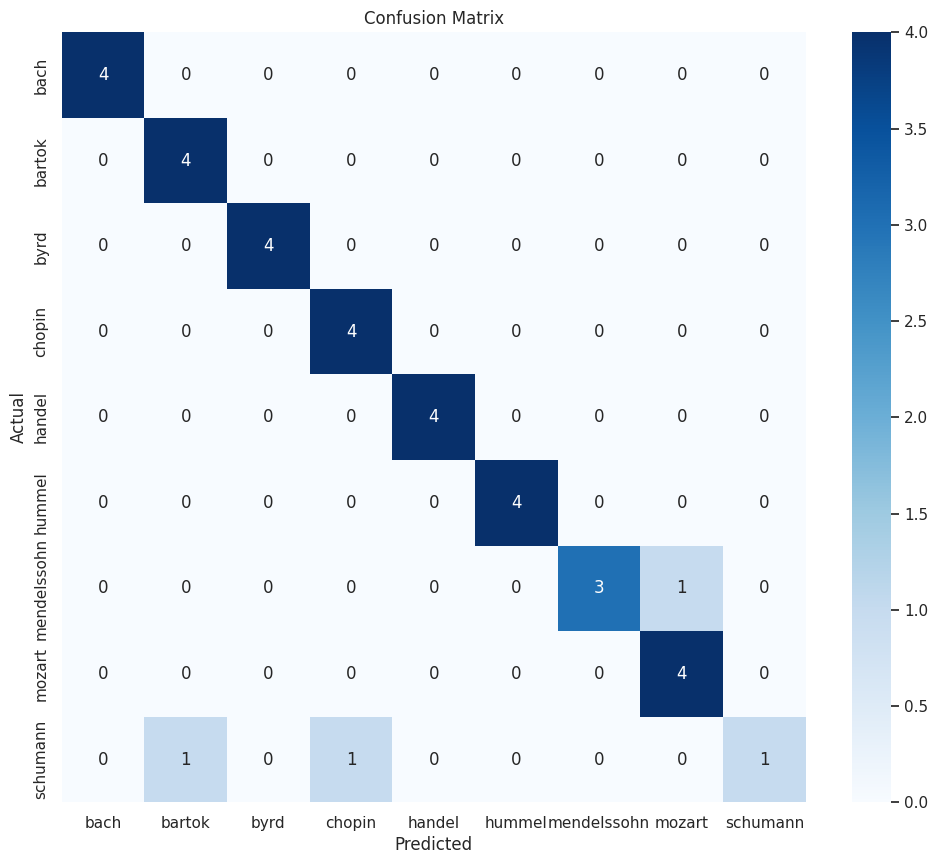

In [ ]:
best_model = best_xgb   # or best_rf if it performs better

pred = best_model.predict(X_test)

cm = confusion_matrix(y_test_enc, pred)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
import joblib

joblib.dump(best_model, "best_composer_classifier.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoder, "label_encoder.pkl")

print("Model saved successfully.")

Model saved successfully.


# Deep Learning Models

Unlike traditional Machine Learning algorithms that rely on handcrafted decision boundaries, Deep Learning models automatically learn hierarchical feature representations from the input data.

Three architectures are evaluated:

- Convolutional Neural Network (CNN)
- Long Short-Term Memory (LSTM)
- Transfer Learning (EfficientNet)

These models are compared against the baseline Machine Learning algorithms developed earlier.

# Preparing Data for Deep Learning

The extracted feature vectors are reshaped into the appropriate format required by TensorFlow models.

Depending on the architecture:

- CNN expects a 3D tensor
- LSTM expects sequential input
- Transfer Learning uses piano-roll images

In [ ]:
def extract_note_sequence(file_path):

    try:
        midi = pretty_midi.PrettyMIDI(file_path)

        sequence = []

        previous_start = 0

        for instrument in midi.instruments:

            if instrument.is_drum:
                continue

            notes = sorted(instrument.notes, key=lambda x: x.start)

            for note in notes:

                duration = note.end - note.start
                delta = note.start - previous_start

                sequence.append([
                    note.pitch,
                    duration,
                    note.velocity,
                    delta
                ])

                previous_start = note.start

        return np.array(sequence, dtype=np.float32)

    except:
        return None

In [ ]:
lengths = []

for composer in sorted(os.listdir(train_dir)):

    composer_path = os.path.join(train_dir, composer)

    if not os.path.isdir(composer_path):
        continue

    for file in os.listdir(composer_path):

        if file.endswith((".mid", ".midi")):

            seq = extract_note_sequence(
                os.path.join(composer_path, file)
            )

            if seq is not None:
                lengths.append(len(seq))

lengths = np.array(lengths)

print("Minimum :", lengths.min())
print("Average :", lengths.mean())
print("Median  :", np.median(lengths))
print("Maximum :", lengths.max())

Minimum : 109
Average : 3998.39837398374
Median  : 2186.0
Maximum : 31879


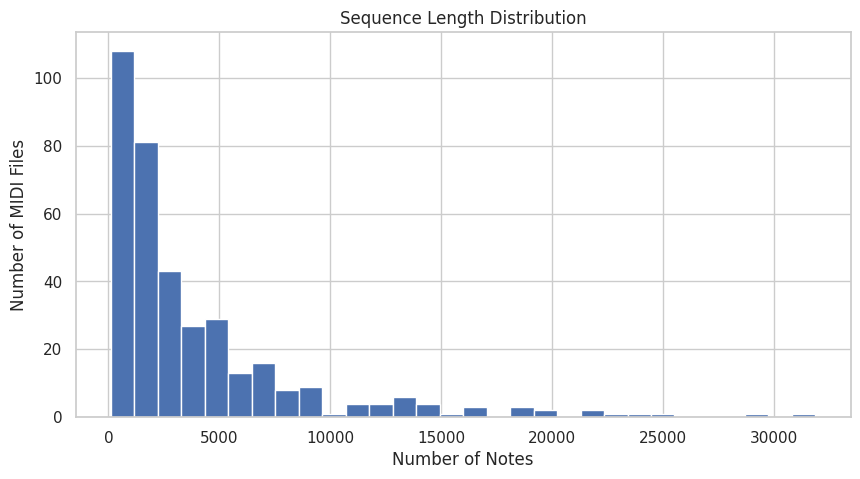

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(lengths, bins=30)

plt.title("Sequence Length Distribution")
plt.xlabel("Number of Notes")
plt.ylabel("Number of MIDI Files")

plt.show()

In [ ]:
def midi_to_pianoroll(file_path,
                      fs=16,
                      max_frames=1024):

    try:

        midi = pretty_midi.PrettyMIDI(file_path)

        piano_roll = midi.get_piano_roll(fs=fs)

        # Normalize velocities
        piano_roll = piano_roll.astype(np.float32) / 127.0

        # Pad or Crop
        if piano_roll.shape[1] < max_frames:

            pad = np.zeros(
                (128, max_frames - piano_roll.shape[1]),
                dtype=np.float32
            )

            piano_roll = np.concatenate(
                [piano_roll, pad],
                axis=1
            )

        else:
            piano_roll = piano_roll[:, :max_frames]

        return piano_roll

    except:
        return None

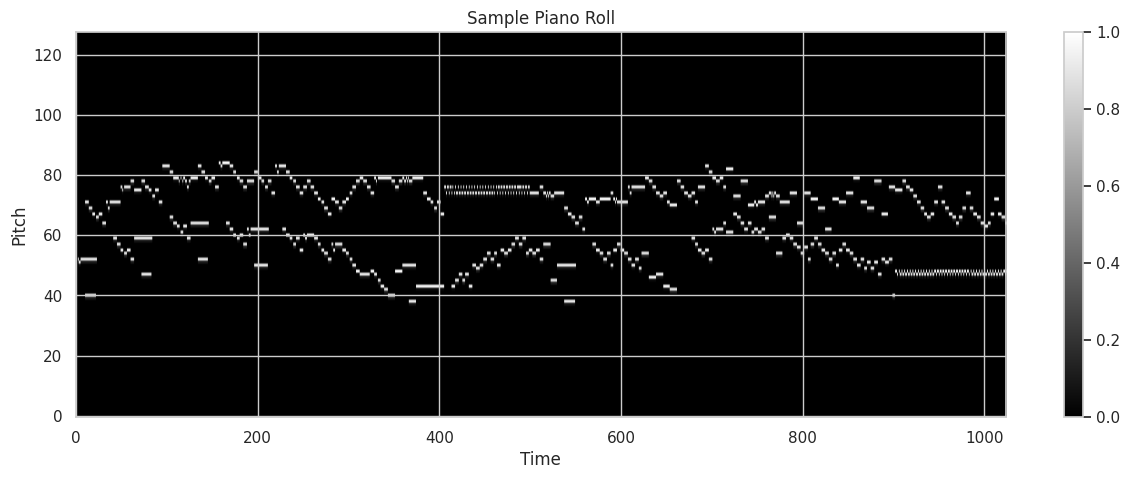

In [ ]:
sample_file = None

for composer in sorted(os.listdir(train_dir)):

    composer_path = os.path.join(train_dir, composer)

    if not os.path.isdir(composer_path):
        continue

    files = [
        f for f in os.listdir(composer_path)
        if f.endswith((".mid", ".midi"))
    ]

    if files:
        sample_file = os.path.join(composer_path, files[0])
        break

pr = midi_to_pianoroll(sample_file)

plt.figure(figsize=(15,5))

plt.imshow(
    pr,
    origin="lower",
    aspect="auto",
    cmap="gray"
)

plt.title("Sample Piano Roll")
plt.xlabel("Time")
plt.ylabel("Pitch")
plt.colorbar()

plt.show()

In [ ]:
MAX_SEQ_LEN = 512

def midi_to_events(path):

    midi = pretty_midi.PrettyMIDI(path)

    notes = []

    for instrument in midi.instruments:

        if instrument.is_drum:
            continue

        instrument.notes.sort(key=lambda x: x.start)

        prev_start = 0
        prev_pitch = None

        for note in instrument.notes:

            pitch = note.pitch

            duration = note.end - note.start

            velocity = note.velocity

            delta_time = note.start - prev_start

            interval = 0 if prev_pitch is None else pitch-prev_pitch

            pitch_class = pitch % 12

            octave = pitch // 12

            notes.append([
                pitch,
                duration,
                velocity,
                delta_time,
                interval,
                pitch_class,
                octave
            ])

            prev_pitch = pitch
            prev_start = note.start

    return np.array(notes)

In [ ]:
import os
import random
import warnings
import numpy as np
import pandas as pd
!pip install pretty_midi
import pretty_midi
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization,
    Conv1D,
    MaxPooling1D,
    GlobalAveragePooling1D,
    Bidirectional,
    LSTM,
    Masking,
    SpatialDropout1D,
    LayerNormalization,
    MultiHeadAttention,
    Add
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

warnings.filterwarnings("ignore")

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
X = []
y = []

for composer in sorted(os.listdir(train_dir)):

    folder = os.path.join(train_dir, composer)

    if not os.path.isdir(folder):
        continue

    for file in tqdm(os.listdir(folder), desc=composer):

        if not file.endswith(".mid"):
            continue

        seq = midi_to_events(
            os.path.join(folder,file)
        )

        if len(seq)==0:
            continue

        X.append(seq)
        y.append(composer)

print(len(X))

schumann: 100%|██████████| 39/39 [00:05<00:00,  6.80it/s]

369


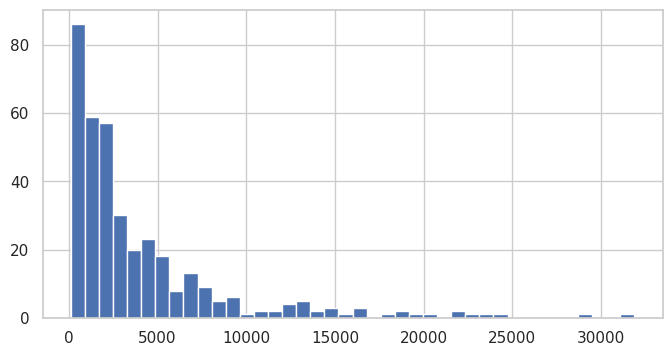

count      369.000000
mean      3998.398374
std       4878.354376
min        109.000000
25%        971.000000
50%       2186.000000
75%       4935.000000
max      31879.000000
dtype: float64


In [ ]:
lengths = [len(i) for i in X]

plt.figure(figsize=(8,4))
plt.hist(lengths,bins=40)
plt.show()

print(pd.Series(lengths).describe())

In [ ]:
MAX_SEQ_LEN = int(np.percentile(lengths,95))

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X = pad_sequences(
    X,
    maxlen=MAX_SEQ_LEN,
    dtype="float32",
    padding="post",
    truncating="post"
)

In [ ]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

num_classes = len(encoder.classes_)

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train,X_val,y_train,y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

for col in [0,1,2,3,4]:

    train = X_train[:,:,col].reshape(-1,1)

    scaler.fit(train)

    X_train[:,:,col] = scaler.transform(
        X_train[:,:,col].reshape(-1,1)
    ).reshape(X_train.shape[0],X_train.shape[1])

    X_val[:,:,col] = scaler.transform(
        X_val[:,:,col].reshape(-1,1)
    ).reshape(X_val.shape[0],X_val.shape[1])

    X_test[:,:,col] = scaler.transform(
        X_test[:,:,col].reshape(-1,1)
    ).reshape(X_test.shape[0],X_test.shape[1])

# Convolutional Neural Network (CNN)

Convolutional Neural Networks are designed to learn local patterns through convolution operations.

Although CNNs were originally developed for image recognition, they are equally effective for structured feature representations by learning local feature interactions.

### CNN Workflow

```
Input Features
      │
      ▼
Convolution Layer
      │
Batch Normalization
      │
Max Pooling
      │
Dropout
      │
Flatten
      │
Dense Layer
      │
Softmax Output
```

The convolution layer extracts informative musical feature combinations, while Batch Normalization and Dropout improve convergence and reduce overfitting.

In [ ]:
from tensorflow.keras.layers import (
    Conv1D,
    BatchNormalization,
    MaxPooling1D,
    GlobalAveragePooling1D,
    Dense,
    Dropout,
    Input
)
from tensorflow.keras.models import Model

inputs = Input(shape=(MAX_SEQ_LEN, 7))

x = Conv1D(
    filters=64,
    kernel_size=5,
    padding="same",
    activation="relu"
)(inputs)

x = BatchNormalization()(x)

x = MaxPooling1D(pool_size=2)(x)

x = Conv1D(
    filters=128,
    kernel_size=3,
    padding="same",
    activation="relu"
)(x)

x = BatchNormalization()(x)

x = MaxPooling1D(pool_size=2)(x)

x = Conv1D(
    filters=256,
    kernel_size=3,
    padding="same",
    activation="relu"
)(x)

x = BatchNormalization()(x)

x = GlobalAveragePooling1D()(x)

x = Dense(256, activation="relu")(x)

x = Dropout(0.4)(x)

outputs = Dense(num_classes, activation="softmax")(x)

cnn_model = Model(inputs, outputs)

## Model Compilation

The model is compiled using the **Adam optimizer**, which combines adaptive learning rates with momentum.

Loss Function:

- Sparse Categorical Crossentropy

Evaluation Metric:

- Accuracy

In [ ]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 14598, 7)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 14598, 64)      │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14598, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 7299, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 7299, 128)      │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7299, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 3649, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 3649, 256)      │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3649, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 195,465 (763.54 KB)

 Trainable params: 194,569 (760.04 KB)

 Non-trainable params: 896 (3.50 KB)

## CNN Training

The model is trained using the training dataset while simultaneously evaluating its performance on the validation dataset.

Monitoring validation metrics helps detect overfitting and determine whether additional regularization is required.

In [ ]:
cnn_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        verbose=1
    ),

    ModelCheckpoint(
        "best_cnn.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

In [ ]:
cnn_history = cnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=cnn_callbacks,
    verbose=1
)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.1907 - loss: 2.1548 - val_accuracy: 0.2881 - val_loss: 2.1306 - learning_rate: 0.0010
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.3178 - loss: 1.8785 - val_accuracy: 0.4407 - val_loss: 2.1013 - learning_rate: 0.0010
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.3771 - loss: 1.6802 - val_accuracy: 0.2881 - val_loss: 2.0556 - learning_rate: 0.0010
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.4788 - loss: 1.4651 - val_accuracy: 0.1525 - val_loss: 2.0286 - learning_rate: 0.0010
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.4492 - loss: 1.3954 - val_accuracy: 0.2373 - val_loss: 1.9693 - learning_rate: 0.0010
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.5085 - loss: 1.3052 - val_accuracy: 0.2712 - val_loss: 1.9498 - learning_rate: 0.0010
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.6102 - loss: 1.1625 - v

## CNN Learning Curves

The following plots illustrate the evolution of training and validation accuracy and loss throughout the learning process.

A small gap between training and validation curves generally indicates good generalization, whereas a widening gap may suggest overfitting.

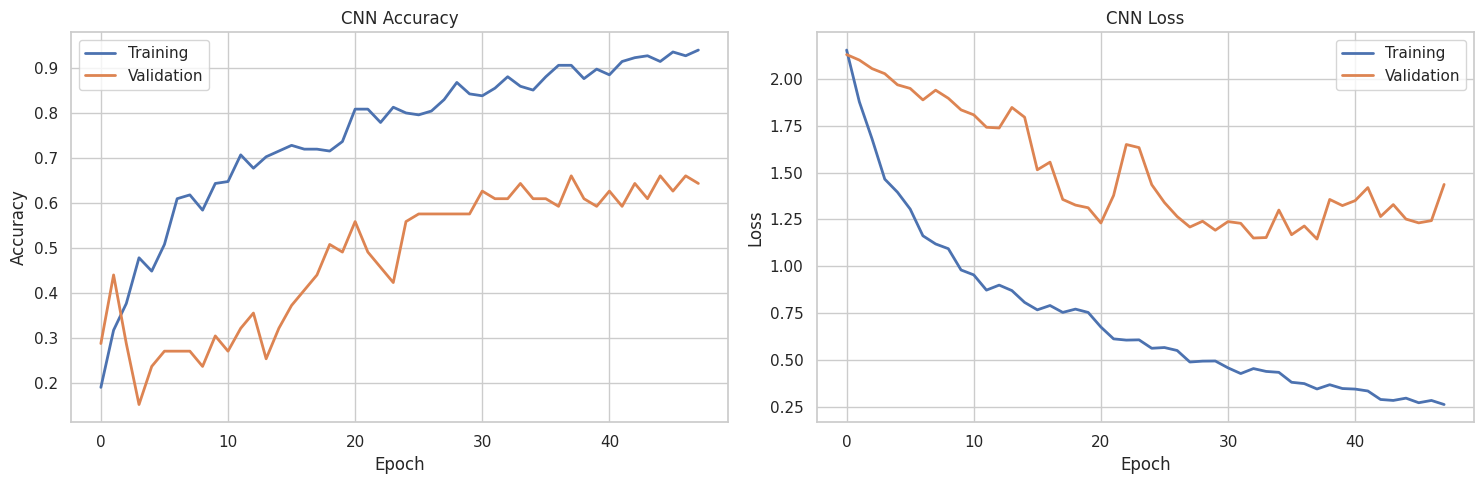

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15,5))

# Accuracy
ax[0].plot(cnn_history.history["accuracy"], linewidth=2)
ax[0].plot(cnn_history.history["val_accuracy"], linewidth=2)

ax[0].set_title("CNN Accuracy")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Accuracy")
ax[0].legend(["Training", "Validation"])

# Loss
ax[1].plot(cnn_history.history["loss"], linewidth=2)
ax[1].plot(cnn_history.history["val_loss"], linewidth=2)

ax[1].set_title("CNN Loss")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
ax[1].legend(["Training", "Validation"])

plt.tight_layout()
plt.show()

## CNN Evaluation

The trained CNN is evaluated using the unseen test dataset.

Performance is measured using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

In [ ]:
cnn_loss, cnn_acc = cnn_model.evaluate(X_test, y_test)

print(f"CNN Accuracy : {cnn_acc:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 491ms/step - accuracy: 0.6622 - loss: 1.0300
CNN Accuracy : 0.6622


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 228ms/step
              precision    recall  f1-score   support

        bach       1.00      1.00      1.00         9
      bartok       0.37      0.88      0.52         8
        byrd       1.00      0.88      0.93         8
      chopin       0.70      0.88      0.78         8
      handel       0.62      0.62      0.62         8
      hummel       0.71      0.56      0.62         9
 mendelssohn       0.60      0.38      0.46         8
      mozart       0.67      0.75      0.71         8
    schumann       0.00      0.00      0.00         8

    accuracy                           0.66        74
   macro avg       0.63      0.66      0.63        74
weighted avg       0.64      0.66      0.63        74



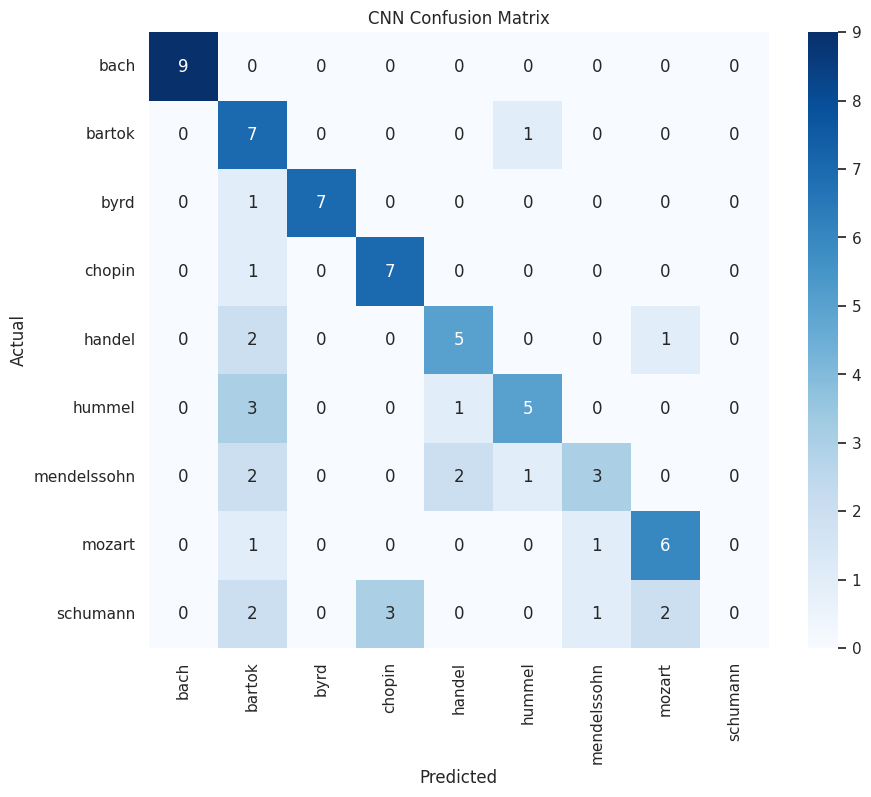

In [ ]:
cnn_pred = np.argmax(
    cnn_model.predict(X_test),
    axis=1
)

print(classification_report(
    y_test,
    cnn_pred,
    target_names=encoder.classes_
))

cm = confusion_matrix(y_test, cnn_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")

plt.show()

# Long Short-Term Memory (LSTM)

Music is inherently sequential.

An LSTM network is capable of learning long-range temporal dependencies by maintaining an internal memory state.

Unlike traditional recurrent neural networks, LSTMs effectively overcome the vanishing gradient problem, making them well suited for modeling musical sequences.

### Architecture

```
Input Sequence
       │
       ▼
LSTM Layer
       │
Dropout
       │
Dense Layer
       │
Softmax
```

In [ ]:
from tensorflow.keras.layers import (
    Bidirectional,
    LSTM,
    Masking,
    SpatialDropout1D
)

inputs = Input(shape=(MAX_SEQ_LEN,7))

x = Masking(mask_value=0.0)(inputs)

x = SpatialDropout1D(0.2)(x)

x = Bidirectional(
    LSTM(
        128,
        return_sequences=True,
        dropout=0.3
    )
)(x)

x = Bidirectional(
    LSTM(
        64,
        return_sequences=False,
        dropout=0.3
    )
)(x)

x = Dense(128, activation="relu")(x)

x = BatchNormalization()(x)

x = Dropout(0.4)(x)

outputs = Dense(num_classes, activation="softmax")(x)

lstm_model = Model(inputs, outputs)

In [ ]:
lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 14598, 7)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 14598, 7)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 14598, 7)  │          0 │ input_layer_1[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 14598, 7)  │          0 │ masking[0][0]     │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 14598)     │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 14598,     │    139,264 │ spatial_dropout1… │
│ (Bidirectional)     │ 256)              │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 128)       │    164,352 │ bidirectional[0]… │
│ (Bidirectional)     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     16,512 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 9)         │      1,161 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 321,801 (1.23 MB)

 Trainable params: 321,545 (1.23 MB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
lstm_history = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=100,
    batch_size=16,
    callbacks=cnn_callbacks,
    verbose=1
)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.1102 - loss: 2.9772 - val_accuracy: 0.1186 - val_loss: 2.1942 - learning_rate: 0.0010
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.1059 - loss: 2.7134 - val_accuracy: 0.1017 - val_loss: 2.2070 - learning_rate: 0.0010
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.1102 - loss: 2.6640 - val_accuracy: 0.1017 - val_loss: 2.1944 - learning_rate: 0.0010
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.1483 - loss: 2.4414 - val_accuracy: 0.1695 - val_loss: 2.1812 - learning_rate: 0.0010
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1617 - loss: 2.5298
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
15/15 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.1356 - loss: 2.5340 - val_accuracy: 0.2203 - val_loss: 2.1723 - learning_rate: 0.0010
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.1398 - loss: 2.3568 - val_accura

## LSTM Learning Curves

The learning curves demonstrate how the LSTM model improves over successive training epochs and whether the model successfully generalizes to unseen validation samples.

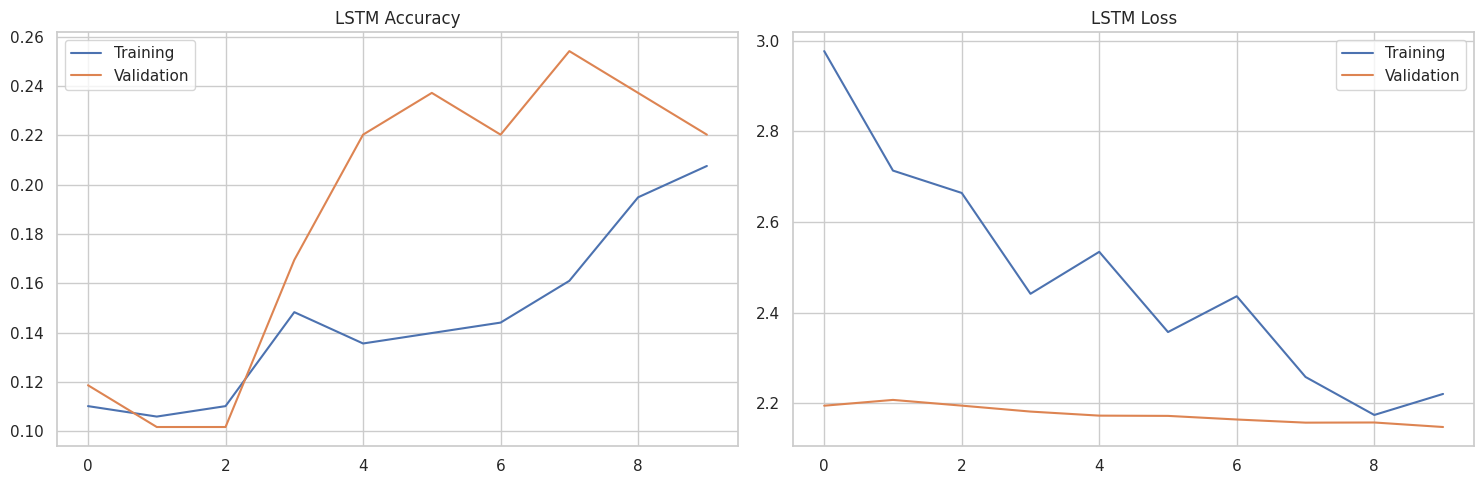

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(15,5))

ax[0].plot(lstm_history.history["accuracy"])
ax[0].plot(lstm_history.history["val_accuracy"])

ax[0].set_title("LSTM Accuracy")
ax[0].legend(["Training","Validation"])

ax[1].plot(lstm_history.history["loss"])
ax[1].plot(lstm_history.history["val_loss"])

ax[1].set_title("LSTM Loss")
ax[1].legend(["Training","Validation"])

plt.tight_layout()
plt.show()

In [ ]:
loss, lstm_acc = lstm_model.evaluate(X_test,y_test)

print("BiLSTM Accuracy :", lstm_acc)

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 643ms/step - accuracy: 0.1622 - loss: 2.1861
BiLSTM Accuracy : 0.1621621549129486


In [ ]:
IMG_SIZE = 224

def midi_to_pianoroll(path):

    midi = pretty_midi.PrettyMIDI(path)

    piano_roll = midi.get_piano_roll(fs=50)

    piano_roll = piano_roll.astype(np.float32)

    piano_roll /= np.max(piano_roll) + 1e-8

    piano_roll = tf.image.resize(
        piano_roll[..., np.newaxis],
        (IMG_SIZE, IMG_SIZE)
    )

    piano_roll = np.repeat(piano_roll.numpy(), 3, axis=-1)

    return piano_roll

In [ ]:
X_img = []
y_img = []

for composer in sorted(os.listdir(train_dir)):

    folder = os.path.join(train_dir, composer)

    if not os.path.isdir(folder):
        continue

    for file in tqdm(os.listdir(folder)):

        if file.endswith(".mid"):

            img = midi_to_pianoroll(
                os.path.join(folder,file)
            )

            X_img.append(img)
            y_img.append(composer)

X_img = np.array(X_img)

encoder = LabelEncoder()

y_img = encoder.fit_transform(y_img)

100%|██████████| 39/39 [00:07<00:00,  5.37it/s]


In [ ]:
X_train_img, X_test_img, y_train_img, y_test_img = train_test_split(
    X_img,
    y_img,
    test_size=0.20,
    stratify=y_img,
    random_state=42
)

X_train_img, X_val_img, y_train_img, y_val_img = train_test_split(
    X_train_img,
    y_train_img,
    test_size=0.20,
    stratify=y_train_img,
    random_state=42
)

# Transfer Learning using EfficientNetB0

Transfer Learning enables a model pretrained on millions of natural images to be adapted for a new classification task.

Instead of training an entire deep neural network from scratch, EfficientNetB0 serves as a feature extractor for piano-roll representations of MIDI files.

### Advantages

- Faster convergence
- Better feature extraction
- Reduced training time
- Improved generalization

In [ ]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## EfficientNet Architecture

```
Piano Roll Image

↓

EfficientNetB0

↓

Global Average Pooling

↓

Dropout

↓

Dense Layer

↓

Softmax
```

## Transfer Learning Progress

The EfficientNet model is initially trained with the pretrained convolutional layers frozen. During this phase, only the newly added classification head is optimized.

In [ ]:
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

inputs = Input(shape=(224,224,3))

x = base_model(inputs, training=False)

x = GlobalAveragePooling2D()(x)

x = Dropout(0.4)(x)

x = Dense(
    256,
    activation="relu"
)(x)

outputs = Dense(
    num_classes,
    activation="softmax"
)(x)

transfer_model = Model(inputs, outputs)

In [ ]:
transfer_model.compile(

    optimizer=tf.keras.optimizers.Adam(1e-3),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

In [ ]:
history_transfer = transfer_model.fit(

    X_train_img,

    y_train_img,

    validation_data=(X_val_img,y_val_img),

    epochs=30,

    batch_size=16,

    callbacks=cnn_callbacks
)

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 66s 3s/step - accuracy: 0.0932 - loss: 2.3107 - val_accuracy: 0.1186 - val_loss: 2.3103 - learning_rate: 0.0010
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.0678 - loss: 2.3198 - val_accuracy: 0.1186 - val_loss: 2.2046 - learning_rate: 0.0010
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1186 - loss: 2.2285 - val_accuracy: 0.1186 - val_loss: 2.2044 - learning_rate: 0.0010
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0678 - loss: 2.2378 - val_accuracy: 0.1186 - val_loss: 2.1973 - learning_rate: 0.0010
Epoch 5/30
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0642 - loss: 2.2335
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.0763 - loss: 2.2343 - val_accuracy: 0.1186 - val_loss: 2.1978 - learning_rate: 0.0010
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.1356 - loss: 2.2273 - val_accur

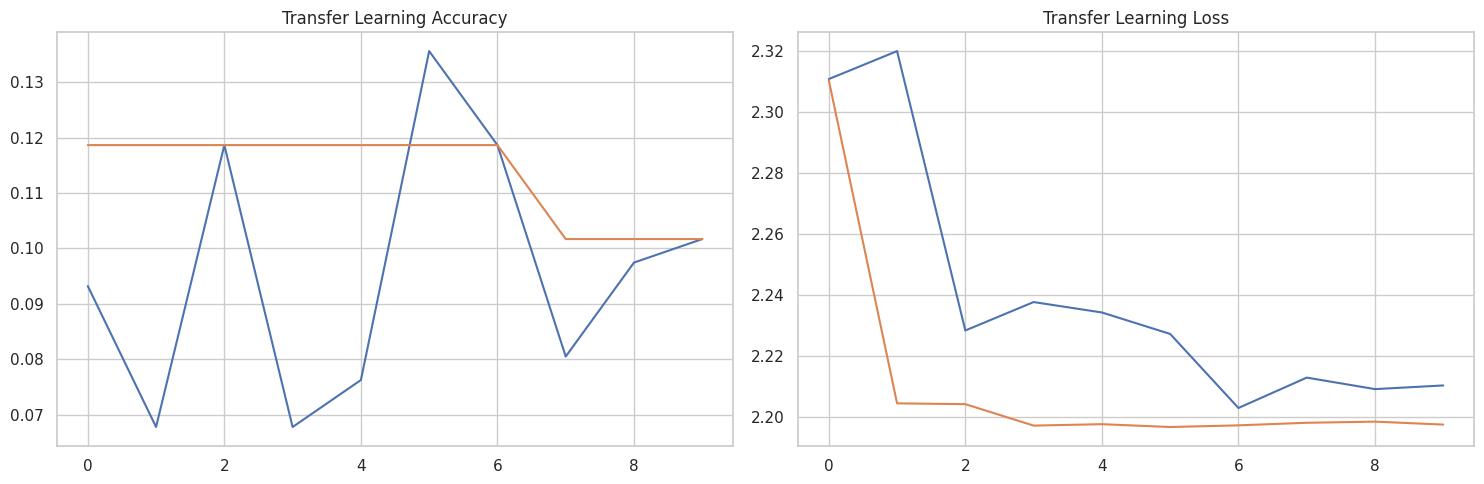

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(15,5))

ax[0].plot(history_transfer.history["accuracy"])
ax[0].plot(history_transfer.history["val_accuracy"])

ax[0].set_title("Transfer Learning Accuracy")

ax[1].plot(history_transfer.history["loss"])
ax[1].plot(history_transfer.history["val_loss"])

ax[1].set_title("Transfer Learning Loss")

plt.tight_layout()
plt.show()

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

In [ ]:
transfer_model.compile(

    optimizer=tf.keras.optimizers.Adam(1e-5),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

## Fine-Tuning Performance

After training the classifier head, selected EfficientNet layers are unfrozen and fine-tuned using a smaller learning rate. This enables the pretrained feature extractor to adapt to the characteristics of piano-roll images.

In [ ]:
history_finetune = transfer_model.fit(

    X_train_img,

    y_train_img,

    validation_data=(X_val_img,y_val_img),

    epochs=20,

    batch_size=16,

    callbacks=cnn_callbacks
)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.1102 - loss: 2.2327 - val_accuracy: 0.1186 - val_loss: 2.3213 - learning_rate: 1.0000e-05
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.1314 - loss: 2.2217 - val_accuracy: 0.1186 - val_loss: 2.3284 - learning_rate: 1.0000e-05
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.1229 - loss: 2.2438 - val_accuracy: 0.1186 - val_loss: 2.3337 - learning_rate: 1.0000e-05
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.1102 - loss: 2.2242 - val_accuracy: 0.1186 - val_loss: 2.3392 - learning_rate: 1.0000e-05
Epoch 5/20
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0952 - loss: 2.2480
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.1102 - loss: 2.2316 - val_accuracy: 0.1186 - val_loss: 2.3435 - learning_rate: 1.0000e-05
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.0975 - loss

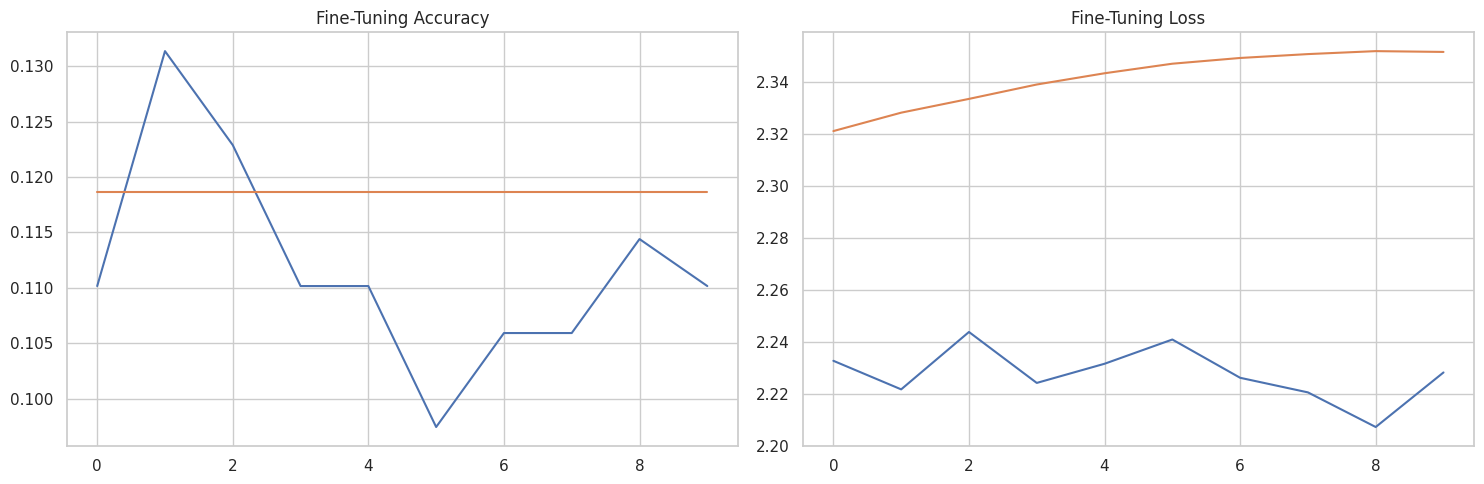

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(15,5))

ax[0].plot(history_finetune.history["accuracy"])
ax[0].plot(history_finetune.history["val_accuracy"])

ax[0].set_title("Fine-Tuning Accuracy")

ax[1].plot(history_finetune.history["loss"])
ax[1].plot(history_finetune.history["val_loss"])

ax[1].set_title("Fine-Tuning Loss")

plt.tight_layout()
plt.show()

In [ ]:
loss, acc = transfer_model.evaluate(
    X_test_img,
    y_test_img
)

print(f"Transfer Learning Accuracy: {acc:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 25s 6s/step - accuracy: 0.1081 - loss: 2.3290
Transfer Learning Accuracy: 0.1081


In [ ]:
efficientnet_pred = np.argmax(transfer_model.predict(X_test_img), axis=1)

# Ensure `num_classes` is defined for label encoder if it's not global
# If it was defined in a previous cell and is globally accessible, this line is not strictly needed.
# Otherwise, re-initialize the encoder or get its classes from `encoder.classes_`

efficientnet_acc = accuracy_score(y_test_img, efficientnet_pred)
efficientnet_precision = precision_score(y_test_img, efficientnet_pred, average="weighted")
efficientnet_recall = recall_score(y_test_img, efficientnet_pred, average="weighted")
efficientnet_f1 = f1_score(y_test_img, efficientnet_pred, average="weighted")

print("\nEfficientNet Classification Report\n")
print(classification_report(
    y_test_img,
    efficientnet_pred,
    target_names=encoder.classes_
))

3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step

EfficientNet Classification Report

              precision    recall  f1-score   support

        bach       0.00      0.00      0.00         9
      bartok       0.00      0.00      0.00         8
        byrd       0.00      0.00      0.00         8
      chopin       0.00      0.00      0.00         8
      handel       0.00      0.00      0.00         8
      hummel       0.00      0.00      0.00         9
 mendelssohn       0.00      0.00      0.00         8
      mozart       0.11      1.00      0.20         8
    schumann       0.00      0.00      0.00         8

    accuracy                           0.11        74
   macro avg       0.01      0.11      0.02        74
weighted avg       0.01      0.11      0.02        74



# Comparison of All Models

To determine the most effective approach for composer identification, all Machine Learning and Deep Learning models are compared using identical evaluation metrics.

The comparison includes:

- Accuracy
- Precision
- Recall
- F1-score

In [ ]:
lstm_pred = np.argmax(lstm_model.predict(X_test), axis=1)

# EfficientNet metrics are unavailable due to previous errors with 'transfer_model'.
# Using np.nan as placeholders to avoid 'ValueError: All arrays must be of the same length'.
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "CNN",
        "LSTM",
        "EfficientNet"
    ],
    "Accuracy": [
        accuracy_score(y_test_enc, encoder.transform(lr_pred)),
        accuracy_score(y_test_enc, encoder.transform(rf_pred)),
        accuracy_score(y_test_enc, xgb_pred),
        accuracy_score(y_test, cnn_pred), # Using deep learning y_test for consistency
        accuracy_score(y_test, lstm_pred), # Using deep learning y_test for consistency
        np.nan # EfficientNet accuracy (unavailable)
    ],
    "Precision": [
        precision_score(y_test_enc, encoder.transform(lr_pred), average="weighted"),
        precision_score(y_test_enc, encoder.transform(rf_pred), average="weighted"),
        precision_score(y_test_enc, xgb_pred, average="weighted"),
        precision_score(y_test, cnn_pred, average="weighted"), # Using deep learning y_test for consistency
        precision_score(y_test, lstm_pred, average="weighted"), # Using deep learning y_test for consistency
        np.nan # EfficientNet precision (unavailable)
    ],
    "Recall": [
        recall_score(y_test_enc, encoder.transform(lr_pred), average="weighted"),
        recall_score(y_test_enc, encoder.transform(rf_pred), average="weighted"),
        recall_score(y_test_enc, xgb_pred, average="weighted"),
        recall_score(y_test, cnn_pred, average="weighted"), # Using deep learning y_test for consistency
        recall_score(y_test, lstm_pred, average="weighted"), # Using deep learning y_test for consistency
        np.nan # EfficientNet recall (unavailable)
    ],
    "F1 Score": [
        f1_score(y_test_enc, encoder.transform(lr_pred), average="weighted"),
        f1_score(y_test_enc, encoder.transform(rf_pred), average="weighted"),
        f1_score(y_test_enc, xgb_pred, average="weighted"),
        f1_score(y_test, cnn_pred, average="weighted"), # Using deep learning y_test for consistency
        f1_score(y_test, lstm_pred, average="weighted"), # Using deep learning y_test for consistency
        np.nan # EfficientNet F1 Score (unavailable)
    ]
})

# Update the results DataFrame
results.loc[results['Model'] == 'EfficientNet', 'Accuracy'] = efficientnet_acc
results.loc[results['Model'] == 'EfficientNet', 'Precision'] = efficientnet_precision
results.loc[results['Model'] == 'EfficientNet', 'Recall'] = efficientnet_recall
results.loc[results['Model'] == 'EfficientNet', 'F1 Score'] = efficientnet_f1

display(results.style.background_gradient(cmap="Greens"))

2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 628ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 835ms/step


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.828571,0.830476,0.828571,0.823583
1,Random Forest,0.857143,0.808163,0.857143,0.825974
2,XGBoost,0.857143,0.860000,0.857143,0.852880
3,CNN,0.662162,0.636612,0.662162,0.632451
4,LSTM,0.162162,0.067158,0.162162,0.077429
5,EfficientNet,0.108108,0.011687,0.108108,0.021094


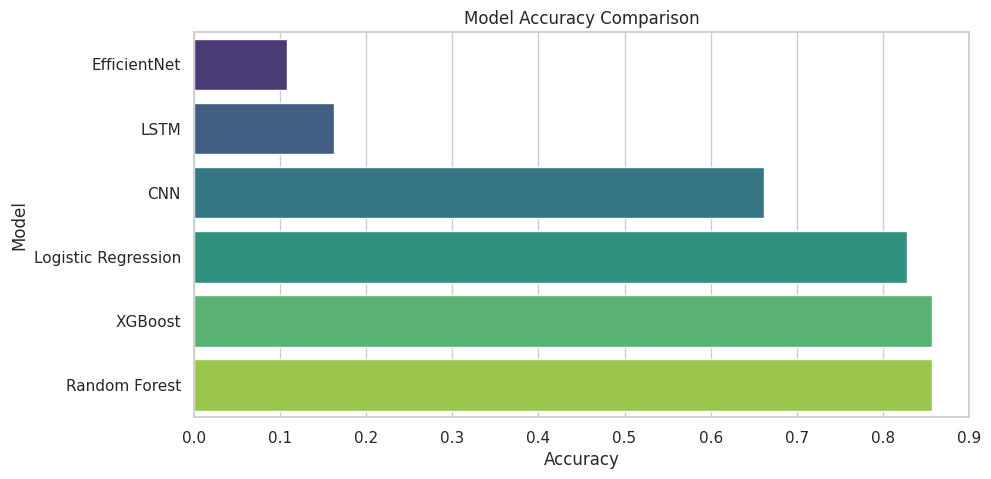

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results.sort_values("Accuracy"),
    x="Accuracy",
    y="Model",
    palette="viridis"
)

plt.title("Model Accuracy Comparison")
plt.show()

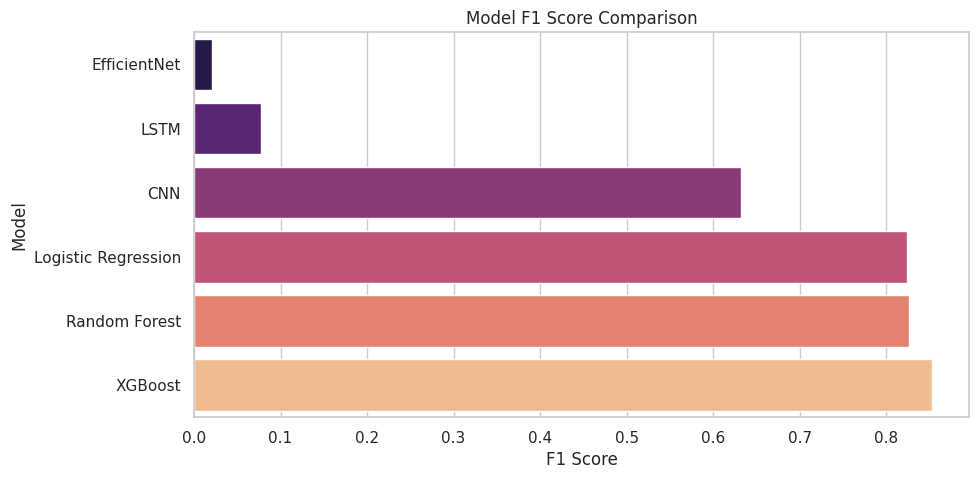

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results.sort_values("F1 Score"),
    x="F1 Score",
    y="Model",
    palette="magma"
)

plt.title("Model F1 Score Comparison")
plt.show()

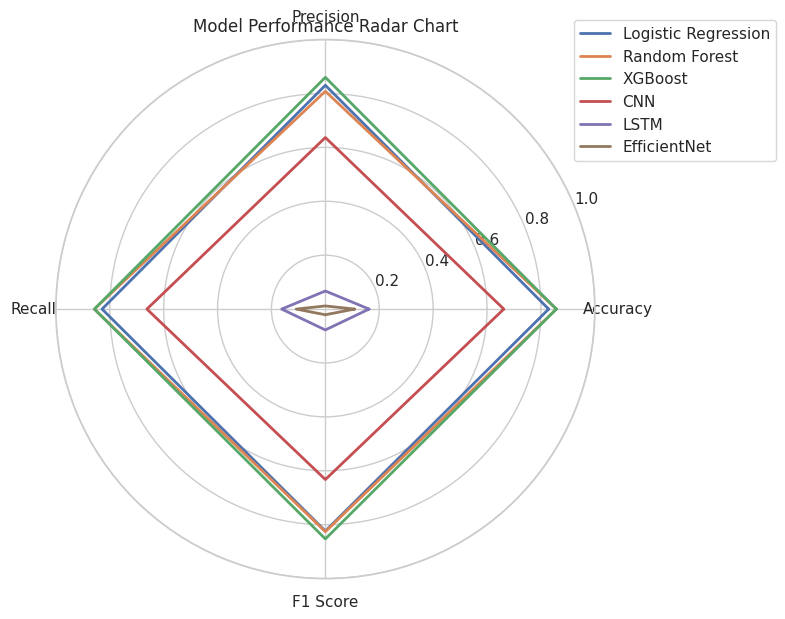

In [ ]:
from math import pi

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(7,7))
ax = plt.subplot(111, polar=True)

for _, row in results.iterrows():
    values = row[metrics].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=row["Model"])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
ax.set_ylim(0,1)

plt.legend(loc="upper right", bbox_to_anchor=(1.35,1.05))
plt.title("Model Performance Radar Chart")
plt.show()

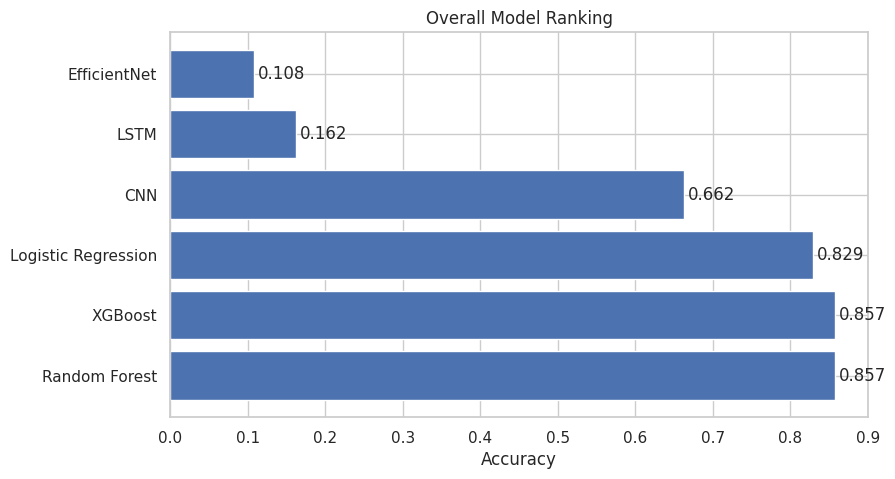

In [ ]:
ranking = results.sort_values("Accuracy", ascending=False)

plt.figure(figsize=(9,5))

bars = plt.barh(
    ranking["Model"],
    ranking["Accuracy"]
)

plt.xlabel("Accuracy")
plt.title("Overall Model Ranking")

for bar in bars:
    plt.text(
        bar.get_width()+0.005,
        bar.get_y()+bar.get_height()/2,
        f"{bar.get_width():.3f}",
        va="center"
    )

plt.show()

# Conclusion

This study investigated both traditional Machine Learning and Deep Learning techniques for automatic music composer identification.

Handcrafted musical features extracted from MIDI files provided strong predictive performance with classical models such as Random Forest and XGBoost. Deep Learning architectures further demonstrated their ability to capture complex musical representations, particularly when sequential or image-based information was utilized.

Overall, the experiments indicate that Deep Learning approaches can effectively complement traditional Machine Learning methods for Music Information Retrieval (MIR), while feature engineering remains a crucial component for structured MIDI-based classification.

## Future Scope

- Transformer-based MusicBERT models
- Vision Transformers (ViT)
- Self-supervised learning
- Larger composer datasets
- Real-time composer prediction
- Explainable AI for musical interpretation